# Team ADAstraPerAspera: Milestone P2

## Introduction

In this notebook, we present the data preprocessing along with the preliminary experiments aimed at answering the following central research question:

> **How do plaques influence the surrounding tissue?**

## Hardware
Throughout this notebook, we comment on the computational feasibility of the proposed methods. To support our claims, we report the execution time of the Python code blocks. For methodological consistency, we will disclose our hardware. All experiments reported in this work were performed on a single laptop machine. We used an Apple MacBook Pro equipped with the Apple M4 system‑on‑chip, and an integrated GPU. The machine has 16 GB of unified memory and a 512 GB solid‑state drive.

---

## Table of Contents

1. **Preliminary Steps**  
   * 1.a. [Imports](#imports)  
   * 1.b. [Loading environment variables and configutations](#loads)
   * 1.c. [Setting up paths to input and output data](#data_path)

2. **Dataset Preprocessing**  
   * 2.a. [Download, preprocess, and format Xenium data](#download)
   * 2.b. [Format the polygons around Aβ-plaque](#format)  
   * 2.c. [Compute cell-to-plaque distances](#compute)
   * 2.d. [Add the plaque-related columns to the cell type annotations](#add_annotations)
   * 2.e. [Attempt to align inter-mouse brain scans](#align_scans)

3. **Exploratory Analysis**  
   * 3.a. [Descriptive statistics on gene expression](#desc)  
   * 3.b. [Expression signal in typical genes](#expr_sig)  
   * 3.c. [Anomaly detection framework](#anomaly)  

4. **Preliminary Analysis**  
   * 4.a. [Visualize the brain regions by plaque proximity](#viz_brain_regio)  

5. **Research Questions**  
   * 5.a. [How does PIG expression change in plaque proximity?](#rq1)  
      * 5.a.i. [Visual analysis](#rq1_visual)  
      * 5.a.ii. [Regression of PIG expression on plaque distance](#rq1_reg)  
      * 5.a.iii. [ANOVA-style analysis of PIG expression in different distance bins](#rq1_anova)  

   * 5.b. [How does cell type composition change in plaque proximity?](#rq2)  
      * 5.b.i. [Joint cell clustering and analysis](#rq2_cell)  

   * 5.c. [Relationship between cell type composition, PIG expression, and plaque distance](#rq3)  
      * 5.c.i. [Correlation matrix between cell type composition and PIG expression](#rq3_corr)  
      * 5.c.ii. [Regression of PIG expression on cell type composition and plaque distance](#rq3_reg)  
      * 5.c.iii. [Visualization of PIG expression by cell type and distance bin](#rq3_viz)  

   * 5.d. [Inferring plaque distance from gene expression](#rq4)  
      * 5.d.i. [Predictive model benchmarking, explainability, and diagnostics](#rq4_pred)  

## 1. **Preliminary Steps**
<a id="imports"></a>  
   ### 1.a. Imports  
   - The imports include standard library modules, third-party libraries, and local modules.  
   - To ensure all third-party libraries are installed, please follow the installation instructions in `docs/setup.md`.

In [ ]:
# Standard Library Imports
import os
from pathlib import Path

# Third-party Library Imports
import pickle
import time
import warnings
import numpy as np
from dotenv import load_dotenv
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from skimage.transform import SimilarityTransform
import yaml

from src.scripts.analysis import predictive_models as pm
from src.scripts.plaque_alignment.config import load_config
from src.scripts.plaque_alignment.utils import (
    fit_transform_with_ransac,
    points_from_keypoints_df,
)
from src.scripts.preprocessing.geometry import (
    compute_cell_to_plaque_distances,
)
from src.scripts.preprocessing.orchestrators import (
    preprocess_cells_and_expression,
    preprocess_plaques,
)
from src.scripts.preprocessing.partition import (
    compute_pigs_zscores,
    compute_weird_gene_scores,
    summarize_genes,
)
from src.scripts.preprocessing.spatial_trends import (
    assign_distance_bins,
    mean_expression_by_bin,
    sem_expression_by_bin,
)
from src.scripts.research_questions.RQ1 import (
    compute_genewise_categorical_anova,
    compute_group_means_for_gene,
    regress_expression_vs_distance,
    summarize_gene_stats,
)

# Local Module Imports
from src.scripts.research_questions.RQ2 import (
    analyze_leiden_spatial,
    analyze_plaque_distance,
    evaluate_cluster_alignment,
    plot_leiden_spatial_grid,
    plot_leiden_umap_grid,
)
from src.scripts.research_questions.RQ3 import (
    analyze_plaque_distance_effects,
    process_cell_annotations,
)
from src.scripts.research_questions.RQ4 import (
    run_gene_distance_modeling,
)
from src.scripts.visualization.interactive_plots import (
    interactive_comp_pig_regression_grid,
)
from src.scripts.visualization.plots import (
    make_image_grid,
    plot_bivariate_resid_distance_spatial,
    plot_cell_to_plaque_map_visible,
    plot_gene_distributions,
    plot_gene_trends,
    plot_half_distance,
    plot_leiden_logit_slopes,
    plot_model_performance,
    plot_pig_comp_heatmap,
    plot_plaques,
    plot_radius_color_spatial,
    plot_residual_vs_distance,
    plot_top_gene_importances,
    plot_true_pred_kde,
)
from src.utils.logging_utils import log_runtime, logger

warnings.filterwarnings("ignore")

_nb_start_time = time.time()

<a id="loads"></a>
### 1.b. Loading environment variables and configutations 

- Before running the cell below, please create a `.env` file in the root directory of the project and add the following variables:
```
BASE_XENIUM_DIR=your/path/to/xenium/data
```
- If successful, the output of the cell will be `True`.

In [2]:
load_dotenv()

True

- Next, we will load the names of:
    - Plaque-Induced Gene (PIG) columns
    - Metadata columns
    - Cell-to-plaque distance columns

In [3]:
# Get absolute path to this notebook's directory
root_dir = os.getcwd()
# Since the configs are part of the repository, this cell shouldn't be modified
config_path = os.path.join(root_dir, "configs/column_annotations.yaml")
statistical_config_path = os.path.join(root_dir, "configs/statistical_constants.yaml")

# Load the contents of configs from YAML into Python dictionaries
with open(os.path.realpath(config_path)) as f:
    config_dict = yaml.safe_load(f)
    PIG_GENES = config_dict["PIG_GENES"]
    meta_cols = config_dict["meta_cols"]
    distance_cols = config_dict["distance_cols"]
with open(os.path.realpath(statistical_config_path)) as f:
    statistical_config_dict = yaml.safe_load(f)
    signif_level = statistical_config_dict["signif_level"]

<a id="data_path"></a>
### 1.c. Setting up paths to input and output data
- In the following cell, we will define:
    - The path to the folder to store the unzipped contents of the Xenium dataset (defined in the step 1.b)
    - Information on the 6 individual mouse components of the Xenium dataset using a single dictionary (do not modify)
    - For each mouse, we provide the following information:
        - The public URL to the Xenium dataset component in `.zip` format
        - The internal path to the folder to store unzipped contents of the Xenium dataset component
        - The internal path to the folder to store preprocessing results
- Most of our analysis focuses on the transgenic mouse with advanced Alzheimer's disease (AD) pathology at 17.9 months of age
- This is because this is the only mouse with an available ImmunoFluorescence (IF) staining of Aβ-plaques
- However, we still perform non-plaque-related analysis on the 5 other mice

In [4]:
# The path to the parent of the folder with unzipped contents of the file downloaded from the link above
base_dir = os.environ["BASE_XENIUM_DIR"]
xenium_config = {
    "tg-17": {
        # This is the public URL to Xenium dataset
        "url": "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_TgCRND8_17_9_months/Xenium_V1_FFPE_TgCRND8_17_9_months_outs.zip",
        # Internal path to files stored in this repository
        "data_folder": "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months",
        # Path to store some preprocessing results; by default this is a subfolder in the Xenium download path
        "output_dir": f"{base_dir}Xenium_V1_FFPE_TgCRND8_17_9_months_outs",
    },
    "tg-5": {
        "url": "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_TgCRND8_5_7_months/Xenium_V1_FFPE_TgCRND8_5_7_months_outs.zip",
        "data_folder": "src/data/Xenium_V1_FFPE_TgCRND8_5_7_months",
        "output_dir": f"{base_dir}Xenium_V1_FFPE_TgCRND8_5_7_months_outs",
    },
    "tg-2": {
        "url": "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_TgCRND8_2_5_months/Xenium_V1_FFPE_TgCRND8_2_5_months_outs.zip",
        "data_folder": "src/data/Xenium_V1_FFPE_TgCRND8_2_5_months",
        "output_dir": f"{base_dir}Xenium_V1_FFPE_TgCRND8_2_5_months_outs",
    },
    "wt-13": {
        "url": "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_wildtype_13_4_months/Xenium_V1_FFPE_wildtype_13_4_months_outs.zip",
        "data_folder": "src/data/Xenium_V1_FFPE_wildtype_13_4_months",
        "output_dir": f"{base_dir}Xenium_V1_FFPE_wildtype_13_4_months_outs",
    },
    "wt-5": {
        "url": "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_wildtype_5_7_months/Xenium_V1_FFPE_wildtype_5_7_months_outs.zip",
        "data_folder": "src/data/Xenium_V1_FFPE_wildtype_5_7_months",
        "output_dir": f"{base_dir}Xenium_V1_FFPE_wildtype_5_7_months_outs",
    },
    "wt-2": {
        "url": "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_wildtype_2_5_months/Xenium_V1_FFPE_wildtype_2_5_months_outs.zip",
        "data_folder": "src/data/Xenium_V1_FFPE_wildtype_2_5_months",
        "output_dir": f"{base_dir}Xenium_V1_FFPE_wildtype_2_5_months_outs",
    },
}

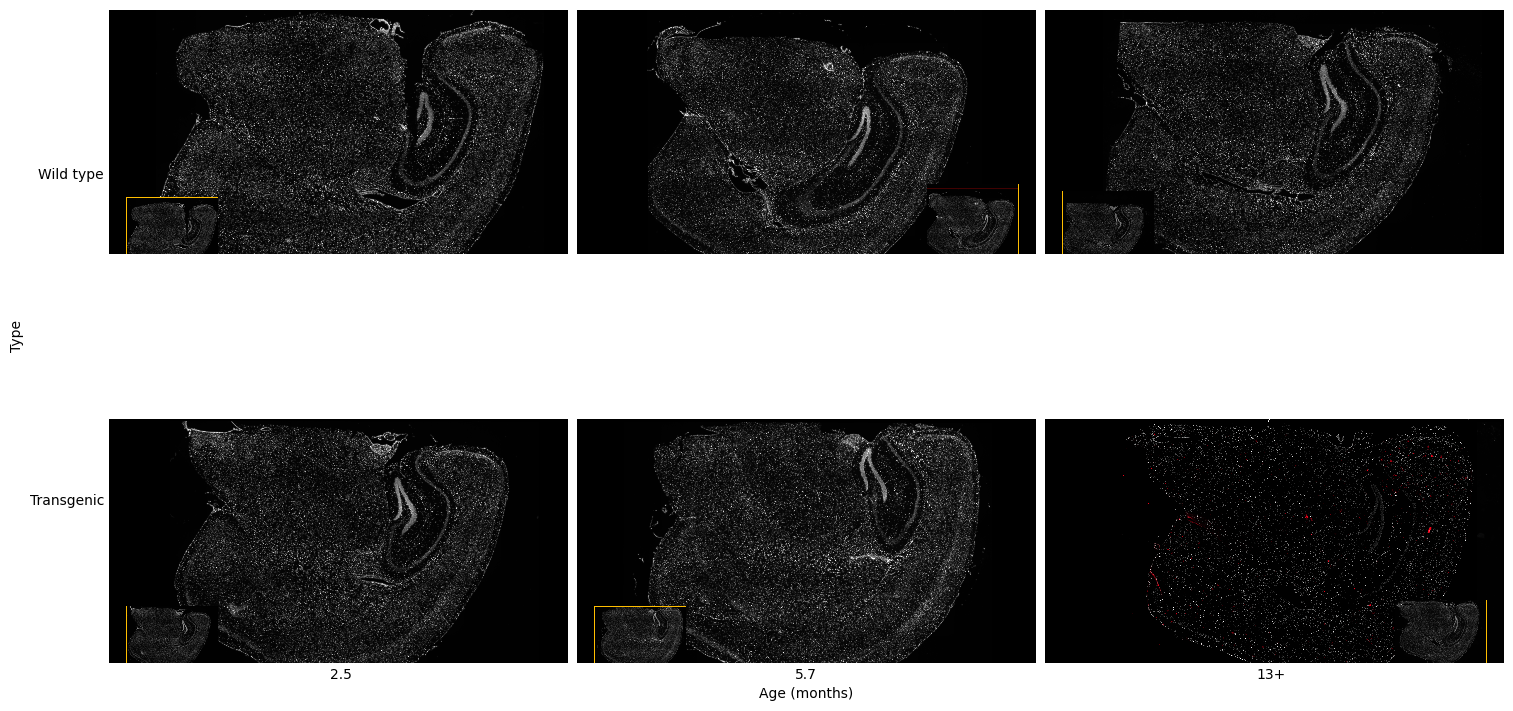

In [5]:
RAW_DIR = Path("src/data/raw_images")  # or Path("raw_images")
FILES: dict[str, Path] = {
    "wt-2": RAW_DIR / "FFPE_wildtype_2_5_months.png",
    "wt-5": RAW_DIR / "FFPE_wildtype_5_7_months.png",
    "wt-13": RAW_DIR / "FFPE_wildtype_13_4_months.png",
    "tg-2": RAW_DIR / "FFPE_TgCRND8_2_5_months.png",
    "tg-5": RAW_DIR / "FFPE_TgCRND8_5_7_months.png",
    "tg-17": RAW_DIR / "FFPE_TgCRND8_17_9_months_plaques.png",
}
KEY_TO_POS: dict[str, tuple[int, int]] = {
    "wt-2": (0, 0),
    "wt-5": (0, 1),
    "wt-13": (0, 2),
    "tg-2": (1, 0),
    "tg-5": (1, 1),
    "tg-17": (1, 2),
}
COL_TICKS = ["2.5", "5.7", "13+"]
ROW_TICKS = ["Wild type", "Transgenic"]
FLIP_H_KEYS = {"wt-5", "tg-17"}

make_image_grid(
    files=FILES,
    key_to_pos=KEY_TO_POS,
    col_ticks=COL_TICKS,
    row_ticks=ROW_TICKS,
    flip_h_keys=FLIP_H_KEYS,
)

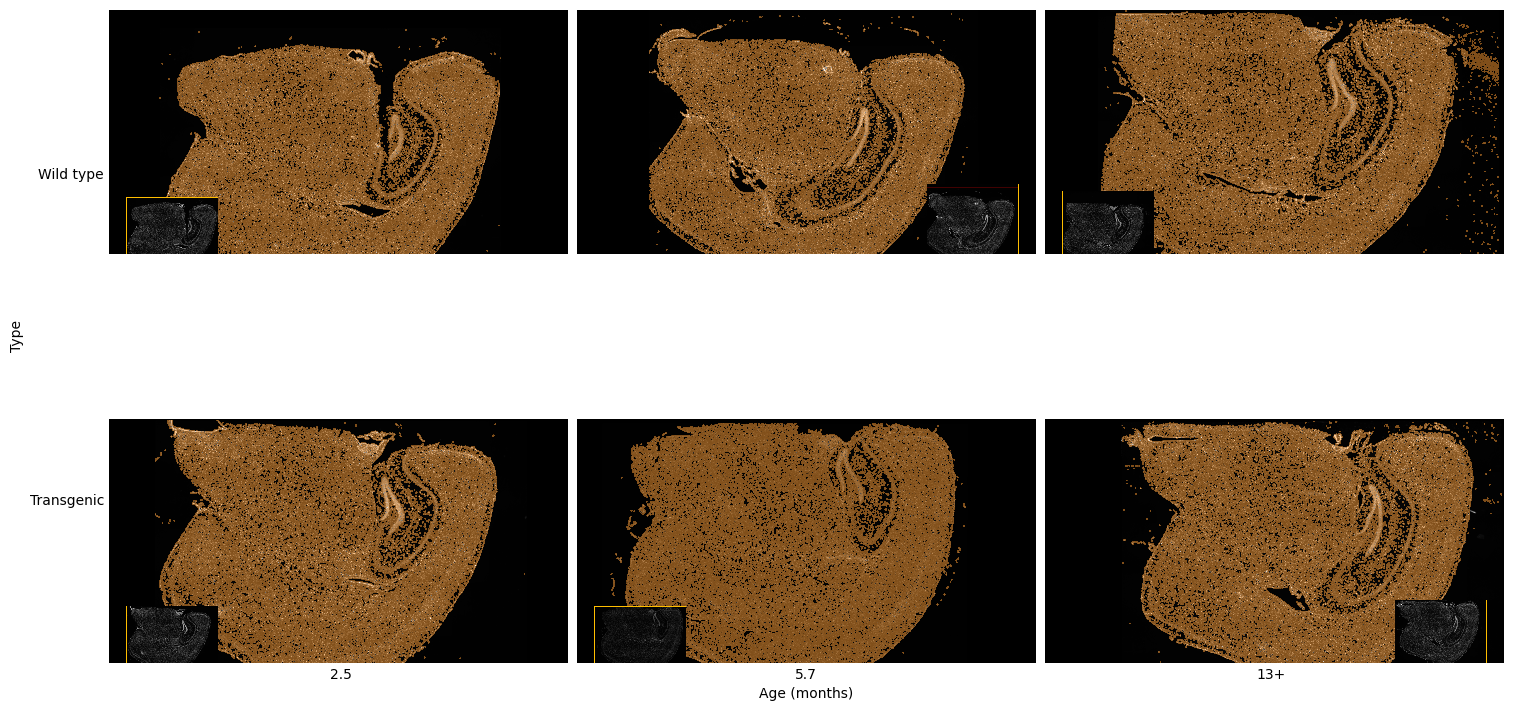

In [6]:
FILES: dict[str, Path] = {
    "wt-2": RAW_DIR / "FFPE_wildtype_2_5_months_cells_unified.png",
    "wt-5": RAW_DIR / "FFPE_wildtype_5_7_months_cells_unified.png",
    "wt-13": RAW_DIR / "FFPE_wildtype_13_4_months_cells_unified.png",
    "tg-2": RAW_DIR / "FFPE_TgCRND8_2_5_months_cells_unified.png",
    "tg-5": RAW_DIR / "FFPE_TgCRND8_5_7_months_cells_unified.png",
    "tg-17": RAW_DIR / "FFPE_TgCRND8_17_9_months_cells_unified.png",
}


make_image_grid(
    files=FILES,
    key_to_pos=KEY_TO_POS,
    col_ticks=COL_TICKS,
    row_ticks=ROW_TICKS,
    flip_h_keys=FLIP_H_KEYS,
)

## 2. **Dataset Preprocessing** 
<a id="download"></a> 
### 2.a. Download, preprocess, and format Xenium data  
- **WARNING: the cell below requires up to 40 GB of disk space**
- The Python block runs a comprehensive preprocessing pipeline `preprocess_cells_and_expression` for all six mice 
- It covers:
    - Xenium's cell data
    - Xenium's gene expression data
- **Data Format**
    - The cell dataframe is constructed from Xenium's `cells.parquet` file which contains the following key columns:
        - `cell_id`: Unique identifier for each cell
        - `x_centroid`: x-coordinate of the cell centroid
        - `y_centroid`: y-coordinate of the cell centroid
        - `nucleus_area`: Area of the polygon approximating the cell nucleus
        - `cell_area`: Area of the polygon approximating the cell membrane contour
        - `transcript_counts`: the number of recorded transcripts for each of the 347 recorded genes in a given cell
    - The expression dataframe is assembled from Xenium's `cell_feature_matrix.h5` file.
        - This file contains 347 colmns, one for each of the recorded genes
- **Missing values**
    - For every mouse, the dataframes derived from `cells.parquet` and `cell_feature_matrix.h5` contains no missing values
    - The missing values were likely pre-handled by Xenium's dataset provider, 10x Genomics
- **Preprocessing pipeline**
    - The key preprocessing steps include:
        - Inner-joining cell and expression data on the `cell_id` column
        - Filter cells falling below the 5th percentile of either of the following quality-control (QC)metrics:
            - Total transcript count
            - Cell area
            - Nucleus area
            - Number of genes with at least 1 recorded transcript
- As part of normalization, we applied a $x \mapsto \log_e(x + 1)$ transformation on the transcript counts to obtain `normalized_counts` dataframe
    - Originally, we planned to use the median-of-ratios method to compute a per-cell normalization factor (i.e., the __size factor__)
    - In this setting, we have 1 row per cell and 1 column per gene
    - However, for all mice,Xenium's gene expression matrices are quite sparse; in fact, every gene has a zero transcript count for at least one cell
    - This leads to zero geometric mean of transcript counts for every gene
    - As a result, every __size factor__ computed by the `PyDESeq2` library is `NaN`
    - Thus, we simply set all __size factor__ values to `1.0` and skip per-cell normalization
- The raw transcript counts are retained in the `preprocessed_counts` dataframe
- The whole preprocessing is feasible as it completes in under 5 minutes (excluding the download time)
- We defer descriptive statistics on `preprocessed_counts` to the section 
    > 3. **Exploratory Analysis**   

In [7]:
preprocessed_datasets = {}
for i, (mouse_age, mouse_config) in enumerate(xenium_config.items()):
    logger.info(f"Preprocessing {mouse_age} data; currently at {i + 1}/{len(xenium_config)}")
    cur_url = mouse_config["url"]
    cur_output_dir = mouse_config["output_dir"]
    cur_path_to_data_folder = mouse_config["data_folder"]
    filtered_combined_df, combined_df_normalized, gene_cols, raw_df = (
        preprocess_cells_and_expression(cur_url, cur_output_dir, cur_path_to_data_folder)
    )
    preprocessed_datasets[mouse_age] = {
        "preprocessed_counts": filtered_combined_df,
        "normalized_counts": combined_df_normalized,
        "raw_counts": raw_df,
        "gene_cols": gene_cols,
    }

Preprocessing tg-17 data; currently at 1/6


Dataset already downloaded in the output directory, skipping.

Loading the data...

Loading cells table from the provided path
Loaded 62268 cells with 10 columns
         cell_id  x_centroid  y_centroid  transcript_counts  \
0  b'aaabiggh-1'  831.785336  755.803772                554   
1  b'aaacfoel-1'  821.733453  768.910446                291   
2  b'aaaeefil-1'  831.932053  780.367651                220   
3  b'aaaehidd-1'  853.614108  774.764157               1029   
4  b'aaagcbkg-1'  821.639603  799.171515                453   

   control_probe_counts  control_codeword_counts  unassigned_codeword_counts  \
0                     0                        0                           0   
1                     0                        0                           0   
2                     1                        0                           0   
3                     0                        0                           0   
4             

In [8]:
total_counts = sum(
    [v["raw_counts"]["transcript_counts"].sum(axis=0) for _, v in preprocessed_datasets.items()]
)
total_cells = sum([v["raw_counts"].shape[0] for _, v in preprocessed_datasets.items()])
all_genes_seen = set()
for _, v in preprocessed_datasets.items():
    all_genes_seen.update(v["gene_cols"])
total_genes = len(all_genes_seen)

logger.info(
    f"Total counts: {total_counts.sum()}, Total cells: {total_cells}, Total genes: {total_genes}"
)

Total counts: 78885074, Total cells: 351714, Total genes: 347


- From the output of the above cell, we have extracted key preprocessing results for each mouse, including:
    - The number of cells before and after filtering
    - The number of gene columns
    - The number of columns with missing values
    - The thresholds used for filtering
    - The size factors used for normalization
- Looking at the results, we can see that for all mice:
    - There are no columns with missing values
    - We have exactly 347 genes
    - All size factors fall back to `1.0` due to the `NaN` output from `PyDESeq2` (due to the fact that every gene has a zero transcript count for at least one cell)
    - The transcript count threshold varies between `41.0` and `81.0`
    - The cell area threshold varies between `62.99` and `79.57`
    - The nucleus area threshold varies between `8.04` and `10.43`
    - The number of genes with at least 1 recorded transcript thresholdvaries between `23.0` and `36.0`


In [9]:
preprocessed_results = {
    "tg-17": {
        "columns_with_nans": 0,
        "thresholds": {
            "transcript_counts": 41.0,
            "cell_area": 66.74,
            "nucleus_area": 8.40,
            "n_genes": 23.0,
        },
        "original_cell_count": 62268,
        "filtered_cell_count": 53895,
        "pydeseq2_out": (
            "PyDESeq2 returned all NaN size factors, falling back to custom implementation. "
            "Global median is 0, setting all size factors to 1.0."
        ),
        "genes_used": 347,
        "size_factors_val": 1.0,
    },
    "tg-5": {
        "columns_with_nans": 0,
        "thresholds": {
            "transcript_counts": 49.0,
            "cell_area": 67.55,
            "nucleus_area": 8.67,
            "n_genes": 25.0,
        },
        "original_cell_count": 58682,
        "filtered_cell_count": 52008,
        "pydeseq2_out": (
            "PyDESeq2 returned all NaN size factors, falling back to custom implementation. "
            "Global median is 0, setting all size factors to 1.0."
        ),
        "genes_used": 347,
        "size_factors_val": 1.0,
    },
    "tg-2": {
        "columns_with_nans": 0,
        "thresholds": {
            "transcript_counts": 66.0,
            "cell_area": 62.99,
            "nucleus_area": 8.72,
            "n_genes": 32.0,
        },
        "original_cell_count": 53913,
        "filtered_cell_count": 47862,
        "pydeseq2_out": (
            "PyDESeq2 returned all NaN size factors, falling back to custom implementation. "
            "Global median is 0, setting all size factors to 1.0."
        ),
        "genes_used": 347,
        "size_factors_val": 1.0,
    },
    "wt-13": {
        "columns_with_nans": 0,
        "thresholds": {
            "transcript_counts": 50.0,
            "cell_area": 76.59,
            "nucleus_area": 8.04,
            "n_genes": 27.0,
        },
        "original_cell_count": 59935,
        "filtered_cell_count": 52753,
        "pydeseq2_out": (
            "PyDESeq2 returned all NaN size factors, falling back to custom implementation. "
            "Global median is 0, setting all size factors to 1.0."
        ),
        "genes_used": 347,
        "size_factors_val": 1.0,
    },
    "wt-5": {
        "columns_with_nans": 0,
        "thresholds": {
            "transcript_counts": 72.0,
            "cell_area": 77.17,
            "nucleus_area": 9.62,
            "n_genes": 33.0,
        },
        "original_cell_count": 58685,
        "filtered_cell_count": 51314,
        "pydeseq2_out": (
            "PyDESeq2 returned all NaN size factors, falling back to custom implementation. "
            "Global median is 0, setting all size factors to 1.0."
        ),
        "genes_used": 347,
        "size_factors_val": 1.0,
    },
    "wt-2": {
        "columns_with_nans": 0,
        "thresholds": {
            "transcript_counts": 81.0,
            "cell_area": 79.57,
            "nucleus_area": 10.43,
            "n_genes": 36.0,
        },
        "original_cell_count": 58231,
        "filtered_cell_count": 51016,
        "pydeseq2_out": (
            "PyDESeq2 returned all NaN size factors, falling back to custom implementation. "
            "Global median is 0, setting all size factors to 1.0."
        ),
        "genes_used": 347,
        "size_factors_val": 1.0,
    },
}

- Let us now explore the preprocessed dataframes for each mouse
- We can see that all tables end up with between 45,000 and 55,000 cells
- Further, all `normalized_counts` dataframes have 357 columns; 347 of which are genes and the rest are metadata columns
- Meanwhile, the `preprocessed_counts` dataframe has 1 additional column `n_genes` which counts the number of genes with at least 1 recorded transcript for each cell

In [10]:
columns_raw, columns_normalized = set(), set()
for k, v in preprocessed_datasets.items():
    logger.info(f"- Mouse: {k} -")
    logger.info(f"Raw dataset shape: {v['preprocessed_counts'].shape}")
    logger.info(f"Log1p normalized dataset shape: {v['normalized_counts'].shape}")
    raw_cols = set(v["preprocessed_counts"].columns)
    norm_cols = set(v["normalized_counts"].columns)
    missing_in_norm = raw_cols - norm_cols
    if missing_in_norm:
        logger.warning(f"Columns in preprocessed but not in normalized counts: {missing_in_norm}")
    columns_raw.update(raw_cols)
    columns_normalized.update(norm_cols)
logger.info(f"Total columns in preprocessed counts: {len(columns_raw)}")
logger.info(f"Total columns in normalized counts: {len(columns_normalized)}")
missing_columns = columns_raw - columns_normalized
logger.info(f"Columns in preprocessed but not in normalized counts: {missing_columns}")

- Mouse: tg-17 -
Raw dataset shape: (53895, 358)
Log1p normalized dataset shape: (53895, 357)
Columns in preprocessed but not in normalized counts: {'n_genes'}
- Mouse: tg-5 -
Raw dataset shape: (52008, 358)
Log1p normalized dataset shape: (52008, 357)
Columns in preprocessed but not in normalized counts: {'n_genes'}
- Mouse: tg-2 -
Raw dataset shape: (47862, 358)
Log1p normalized dataset shape: (47862, 357)
Columns in preprocessed but not in normalized counts: {'n_genes'}
- Mouse: wt-13 -
Raw dataset shape: (52753, 358)
Log1p normalized dataset shape: (52753, 357)
Columns in preprocessed but not in normalized counts: {'n_genes'}
- Mouse: wt-5 -
Raw dataset shape: (51314, 358)
Log1p normalized dataset shape: (51314, 357)
Columns in preprocessed but not in normalized counts: {'n_genes'}
- Mouse: wt-2 -
Raw dataset shape: (51016, 358)
Log1p normalized dataset shape: (51016, 357)
Columns in preprocessed but not in normalized counts: {'n_genes'}
Total columns in preprocessed counts: 358
To

- Next, we will merge the pre-processed dataframes with the cell type annotations
- Cell type annotations were obtained by running Leiden clustering

In [11]:
# Use pickled clustering results to infer cell types
clustering_results = pickle.load(open("src/data/clustering.pkl", "rb"))
columns_seen = set()
for mouse_age, data in preprocessed_datasets.items():
    logger.info(f"- Mouse: {mouse_age} -")
    annotated_cells = clustering_results["joint_res"].df_by_mouse[mouse_age][
        ["cell_id", "cluster_leiden"]
    ]
    annotated_cells.rename(columns={"cluster_leiden": "cell_type"}, inplace=True)
    normalized_counts = data["normalized_counts"]
    raw_counts = data["preprocessed_counts"]
    len_overlap = sum(annotated_cells["cell_id"].isin(normalized_counts["cell_id"]))
    len_normalized = len(normalized_counts)
    logger.info(
        f"- Cell ID overlap: {len_overlap} / {len_normalized} ({len_overlap / len_normalized * 100:.2f}%)"
    )
    annotated_cells_original = annotated_cells.copy()
    annotated_cells = annotated_cells.merge(
        normalized_counts,
        on="cell_id",
        how="inner",  # or 'inner', depending on what you want
    )
    annotated_cells_raw_counts = annotated_cells_original.merge(
        raw_counts,
        on="cell_id",
        how="inner",  # or 'inner', depending on what you want
    )

    preprocessed_datasets[mouse_age]["annotations"] = annotated_cells
    preprocessed_datasets[mouse_age]["annotations_raw_counts"] = annotated_cells_raw_counts
    annotated_cells.to_csv(
        f"{xenium_config[mouse_age]['data_folder']}/normalized_annotations_for_{mouse_age}.csv",
        index=False,
    )
    annotated_cells_raw_counts.to_csv(
        f"{xenium_config[mouse_age]['data_folder']}/preprocessed_annotations_for_{mouse_age}.csv",
        index=False,
    )
    logger.info(
        f"Shape of annotated cells after filtering out diverging cells: {annotated_cells.shape}"
    )
    logger.info("Columns with NaNs:\n%s", annotated_cells.isnull().sum()[lambda s: s > 0])
    columns_seen.update(annotated_cells.columns)
    logger.info(
        f"Shape of normalized counts after filtering out diverging cells: {preprocessed_datasets[mouse_age]['normalized_counts'].shape}"
    )
    logger.info(
        f"Shape of preprocessed counts after filtering out diverging cells: {preprocessed_datasets[mouse_age]['preprocessed_counts'].shape}"
    )
logger.info(f"Total columns seen: {len(columns_seen)}")

- Mouse: tg-17 -
- Cell ID overlap: 53895 / 53895 (100.00%)
Shape of annotated cells after filtering out diverging cells: (53895, 358)
Columns with NaNs:
Series([], dtype: int64)
Shape of normalized counts after filtering out diverging cells: (53895, 357)
Shape of preprocessed counts after filtering out diverging cells: (53895, 358)
- Mouse: tg-5 -
- Cell ID overlap: 52008 / 52008 (100.00%)
Shape of annotated cells after filtering out diverging cells: (52008, 358)
Columns with NaNs:
Series([], dtype: int64)
Shape of normalized counts after filtering out diverging cells: (52008, 357)
Shape of preprocessed counts after filtering out diverging cells: (52008, 358)
- Mouse: tg-2 -
- Cell ID overlap: 47862 / 47862 (100.00%)
Shape of annotated cells after filtering out diverging cells: (47862, 358)
Columns with NaNs:
Series([], dtype: int64)
Shape of normalized counts after filtering out diverging cells: (47862, 357)
Shape of preprocessed counts after filtering out diverging cells: (47862, 35

- We will now save the pre-processed dataframes to the disk

In [12]:
for mouse_age, data in preprocessed_datasets.items():
    data["preprocessed_counts"].to_csv(
        f"{xenium_config[mouse_age]['data_folder']}/preprocessed_counts_{mouse_age}.csv",
        index=False,
    )
    data["normalized_counts"].to_csv(
        f"{xenium_config[mouse_age]['data_folder']}/normalized_counts_{mouse_age}.csv", index=False
    )

<a id="format"></a>
### 2.b. Format the polygons around Aβ-plaque  

#### Plaque Identification Pipeline
- The plaque polygons were defined by broadly following the approach in [Xenium's application note](https://pages.10xgenomics.com/rs/446-PBO-704/images/10x_LIT000210_App-Note_Xenium-In-Situ_Letter_Digital.pdf)

##### Raw data format

- In the Xenium Alzheimer Disease experiment, the Aβ plaques were stained with antibodies and later visualized with immunofluorescence (IF) microscopy.
- As a result, 10X Genomics provides `Xenium_V1_FFPE_TgCRND8_17_9_months_if_image.ome.tif` file with the IF data.
- This file contains two channels called `slice:1` and `slice:3`.
- `slice:1` contains coarse, unevenly spaced groups of bright pixels that represent the amyloid beta plaques.
- `slice:3` contains small and evenly spaced bright pixels that represent the nuclei of the cells.
- To identify the plaques, we restricted the analysis only to the `slice:1` channel.

##### Data labeling

- We produced 11 data points carrying rectangles around plaque-free regions (negative samples).
- Similarly, we labeled 9 data points with hand-drawn polygons around plaques (positive samples).
- We then used the object classifier from [QuPath](https://www.nature.com/articles/s41598-017-17204-5), employing the labeled points for training.
- We selected the default implementation of the random trees based classifier which tends to work better with the limited amount of training data.
- We then used the classifier to identify the plaques in the `slice:1` channel.
- The resulting objects (along with the ground truth labels used to train the classifier) are stored in `src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/Xenium_V1_FFPE_TgCRND8_17_9_months_if_image.qpdata`
- Only the predicted plaque polygons are exported to `src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/qupath_plaque_polygons.geojson`
- However, these coordinates are mismatched from the morphology coordinate space.
- And morphology coordinate space hosts all the cell coordinates loaded previously.
- Thus, we need to align the obtained plaque polygons to the morphology image.

##### Aligning the IF image to the morphology image

- To align IF image to the morphology space, we produced 26 keypoint pairs around important anatomical landmarks.
- These keypoints constitute a map between the two images.
- In other words, each pair contains closely visually aligned points on the IF image and the morphology image.
- These keypoints are stored in `src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/image_keypoints.csv`
- To reiterate, this file provides matched 2D control points relating `Xenium_V1_FFPE_TgCRND8_17_9_months_if_image.ome.tif` and `morphology_focus.ome.tif`
- The CSV columns of this file are:
- `fixedX`, `fixedY`: coordinates in the fixed/reference image, which is the morphology image.
- `alignmentX`, `alignmentY`: coordinates in the other image to be aligned, which is the IF image in our case.
- Next, we set up a transformation function that maps the keypoints from the IF image as closely as possible on average to their corresponding counterparts in the morphology image. This transformation is inferred by minimizing the following loss function:

$$
\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^{N} \left\| T_\theta(\mathbf{p}^{(i)}_{\text{IF}}) - \mathbf{p}^{(i)}_{\text{morph}} \right\|_2^2
$$

where:
- $T_\theta$ is the estimated transformation (we evaluated a `SimilarityTransform` and an `AffineTransform`),
- $\mathbf{p}^{(i)}_{\text{IF}} = (x^{(i)}_{\text{IF}}, y^{(i)}_{\text{IF}})$ are keypoints in the IF image,
- $\mathbf{p}^{(i)}_{\text{morph}} = (x^{(i)}_{\text{morph}}, y^{(i)}_{\text{morph}})$ are corresponding keypoints in the morphology image,
- and $N$ is the total number of matched keypoints ($N = 26$ in our case).  

- Namely, these key points were used to train a `SimilarityTransform` (RANSAC) model (which proved to perform better than an `AffineTransform`), resulting in a root mean squared error of 15.213 pixels or 15.213 * 0.2125 µm = 3.231 µm (microns), which is considered acceptable for our purposes.
- Note that in the above calculation, we are using the size of the pixel of 0.2125 µm as given by the 10x Genomics [documentation](https://kb.10xgenomics.com/s/article/11636252598925-What-are-the-Xenium-image-scale-factors).

- To repeat this analysis, run the following simple command below:

```bash
# Run from the root directory of the project
export PYTHONPATH="$PWD/src"
python -m scripts.plaque_alignment.cli --config configs/plaque_alignment.yaml
```
##### Transforming the plaque polygons

- Next, we applied the learned transformation to the plaque polygons.
- As a result, we obtained 1938 exterior polygons surrounding the plaques.
- The transformed plaque polygons which are stored in `src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/plaque_polygons.csv`
- Importing these transformed polygons into the Xenium Explorer reveals close visual alignment with the morphology image, as visible in **Figure 1** below:

![Figure 1 — Formatted Xenium UI Polygons](src/data/figures/Formatted_Xenium_UI_Polygons.png)

#### Further preprocessing

- Next, we apply additional preprocessing steps:
    - Every polygon around a plaque is closed and converted to a `shapely.geometry.Polygon` instance.
    - Namely, we coerce every plaque outline into a valid polygon, which is a planar surface bounded by one exterior linear ring and zero or more interior linear rings (holes). 
    - Rings must be closed and simple; if rings cross, the polygon is invalid as per [Shapely documentation](https://shapely.readthedocs.io/en/2.0.6/reference/shapely.Polygon.html)
    - Whenever feasible, we replace every non-convex polygon with a convex hull encompassing its interior.

- Finally, we apply plaque filtering as outlined below:
- Let $\mathcal{P}=\{P_1,\dots,P_n\}$ be the set of candidate plaques, each $P_i\subset\mathbb{R}^2$ a polygonal region.  
- Let $B\subset\mathbb{R}^2$ be the hand-drawn brain boundary polygon.  
- Let $A_i$ denote the polygon's area given by $\mu(P_i)$.

We will only permit the plaques that satisfy the following criteria:

1. **No mutual intersections.** For all distinct $i,j\in\{1,\dots,n\}$,
   $$
   P_i\cap P_j=\varnothing.
   $$

2. **Each plaque touches the brain boundary.** For all $i$,
   $$
   P_i\cap B\neq\varnothing.
   $$

- Let us denote those plaques which satisfy the two criteria above as $\mathcal{P}^{\mathrm{valid}}$. 
- In our setup, the set $\mathcal{P}^{\mathrm{valid}}$ contains 1,828 plaques (out of 1,938 candidate plaques produces by QuPath software).
- This set will be further filtered by cutting off the plaques with areas below the 5th percentile.  
- Namely, we compute the empirical 5th percentile of areas over $\mathcal{P}^{\mathrm{valid}}$,
$$
t
\;:=\;
\operatorname{Quantile}_{0.05}\bigl(\{\,A_i:\;P_i\in\mathcal{P}^{\mathrm{valid}}\,\}\bigr).
$$

- Finally, we keep only those plaques whose area is no less than the threshold $t$:
$$
\mathcal{P}^{\mathrm{valid\&filtered}}
\;:=\;
\bigl\{\,P_i\in\mathcal{P}^{\mathrm{valid}}:\ A_i\ge t\,\bigr\}.
$$
- The resulting set of plaques, $\mathcal{P}^{\mathrm{valid\&filtered}}$, is bound to the `plaques_poly` Pandas dataframe.
- After applying the area cutoff, we kept 1,736 out of 1,828 plaques (95.0%).
- A visualization of the final set of closed, filtered, and mostly convex plaques is shown in the output of the following cell.
    - We can confirm that out of all plaques in the final set, only 25 are non-convex
    - All plaques are closed and are intersecting with the brain boundary
- All of the aforementioned steps, from plaque polygon inference with a random forest classifier to the final filtering, are feasible as they complete in under 10 minutes



Loading the plaque data...


Loading the brain polygon...

plaques_long: 161,308 vertices | plaques_poly: 1,938 polygons | brain polygon valid: True

Filtering the plaques...

{'n_final': 1828, 'polygons': 1828, 'multipolygons': 0, 'holes_present': 1, 'convex': 1803}
Kept after area cutoff: 1,736 out of 1,828
{'total': 1736, 'convex': 1711, 'non_convex': 25, 'holes_present': 1, 'mean_area': 133.9314068292565, 'in_brain': 1.0}


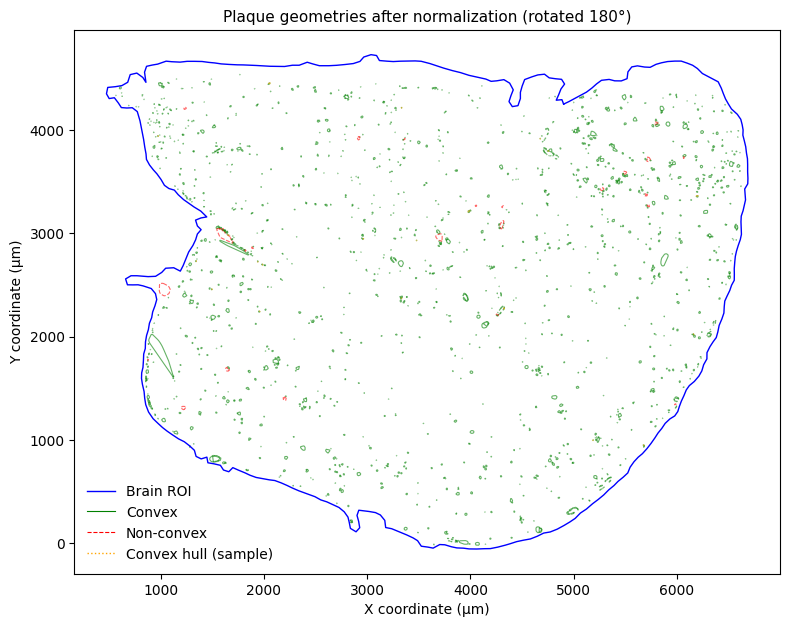

In [13]:
plaques_poly, brain_geom = preprocess_plaques(xenium_config["tg-17"]["data_folder"])
logger.info(
    {
        "total": len(plaques_poly),
        "convex": plaques_poly["is_convex"].sum(),
        "non_convex": (~plaques_poly["is_convex"]).sum(),
        "holes_present": plaques_poly["has_holes"].sum(),
        "mean_area": plaques_poly["area"].mean(),
        "in_brain": plaques_poly["in_brain"].mean(),
    }
)
ax = plot_plaques(
    plaques_poly,
    brain_geom=brain_geom if "brain_geom" in globals() else None,
    sample_hulls=20,
    seed=42,
    figsize=(8, 8),
)

<a id="compute"></a>
### 2.c. Compute cell-to-plaque distances  
- For each cell, we will compute the distance to the nearest preprocessed plaque and store it in the `distance_to_plaque` column of the `combined_df_normalized` dataframe
- The resulting distance between the cell centroid to the closest plaque boundary is measured in µm
- As outlined in the previous section, the preprocessed plaques are comprising the set $\mathcal{P}^{\mathrm{valid\&filtered}}$ of size $K$.
- Let the set of cells be $\{C_i\}_{i=1}^N$ with centroids $c_i$.
- For each cell, we will compute Euclidean distance $d_i$ from its centroid $c_i$ to the set of points comprising nearest plaque $P_{k^*(i)}$ as:
$$
d_i \;=\; \operatorname{dist}(c_i, P_{k^*(i)})
\;=\; \inf_{y \in P_{k^*(i)}} \|c_i - y\|_2,
\quad i=1,\dots,N.
$$
- In the expression above, the plaque $P_{k^*(i)}$ nearest to the cell $C_i$ is defined as:
$$
k^*(i) \;\in\; \arg\min_{1 \le k \le K}\; \operatorname{dist}(c_i, P_k).
$$
- As a result of the above procedure, no cells have missing nearest plaque distance (see output of the following cell).
- Finally, we will use inner join on `cell_id` to merge the `distance_to_plaque` column into the `combined_df_normalized` dataframe.
- The computation is feasible as it completes in under 1 minute

In [14]:
normalized_counts = preprocessed_datasets["tg-17"]["normalized_counts"]
preprocessed_counts = preprocessed_datasets["tg-17"]["preprocessed_counts"]
normalized_counts_filtered = normalized_counts[
    normalized_counts["cell_id"].isin(preprocessed_datasets["tg-17"]["annotations"]["cell_id"])
]
preprocessed_counts_filtered = preprocessed_counts[
    preprocessed_counts["cell_id"].isin(preprocessed_datasets["tg-17"]["annotations"]["cell_id"])
]

filtered_combined_df_full, combined_df_normalized = (
    preprocessed_counts_filtered,
    normalized_counts_filtered,
)
cells_with_distances = compute_cell_to_plaque_distances(filtered_combined_df_full, plaques_poly)
combined_df_normalized_full = combined_df_normalized.merge(
    cells_with_distances[
        [
            "cell_id",
            "distance_to_plaque",
            "nearest_plaque_center_dist",
            "inside_any_plaque",
            "nearest_plaque_id",
            "nearest_plaque_area",
        ]
    ],
    on="cell_id",
    how="inner",
)
logger.info(
    f"Number of cells with missing nearest plaque distance: {combined_df_normalized_full['distance_to_plaque'].isna().sum()}"
)

Computing distances: 100%|█████████████████████████████████| 53895/53895 [00:02<00:00, 21437.03it/s]


{'cells': 53895, 'plaques_used': 1736}
Number of cells with missing nearest plaque distance: 0


<a id="add_annotations"></a>
### 2.d. Add the plaque-related columns to the cell type annotations

In [15]:
PATH_TO_ANNOTATIONS = (
    "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/preprocessed_annotations_for_tg-17.csv"
)
combined_tg_17 = pd.read_csv("src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/combined.csv")
cells = pd.read_parquet(f"{base_dir}/Xenium_V1_FFPE_TgCRND8_17_9_months_outs/cells.parquet")
annotations_for_tg_17 = pd.read_csv(PATH_TO_ANNOTATIONS)
annotations_overlap_filtered = sum(
    annotations_for_tg_17["cell_id"].isin(combined_df_normalized_full["cell_id"])
)
annotations_overlap_combined_df = sum(
    annotations_for_tg_17["cell_id"].isin(combined_tg_17["cell_id"])
)
annotations_overlap_raw_cells = sum(
    annotations_for_tg_17["cell_id"].isin(cells["cell_id"].str.decode("utf-8"))
)
annotations_overlap_annotations = sum(
    annotations_for_tg_17["cell_id"].isin(annotations_for_tg_17["cell_id"])
)
logger.info(
    " - Sizes of overlaps b/w annotations and Xenium data -\n\n"
    f"Total annotated cells (annotations x annotations for Tg 17.9 months): {annotations_overlap_annotations:,}\n"
    f"Cells both in annotations for Tg 17.9 months and raw cells parquet for Tg 17.9 months: "
    f"{annotations_overlap_raw_cells:,} ({annotations_overlap_raw_cells / annotations_overlap_annotations * 100:.2f}%)\n"
    f"Cells both in annotations for Tg 17.9 months and combined cells and expression csv: "
    f"{annotations_overlap_combined_df:,} ({annotations_overlap_combined_df / annotations_overlap_annotations * 100:.2f}%)\n"
    f"Cells both in annotations for Tg 17.9 months and the filtered dataframe: "
    f"{annotations_overlap_filtered:,} ({annotations_overlap_filtered / annotations_overlap_annotations * 100:.2f}%)"
)

 - Sizes of overlaps b/w annotations and Xenium data -

Total annotated cells (annotations x annotations for Tg 17.9 months): 53,895
Cells both in annotations for Tg 17.9 months and raw cells parquet for Tg 17.9 months: 49,945 (92.67%)
Cells both in annotations for Tg 17.9 months and combined cells and expression csv: 53,895 (100.00%)
Cells both in annotations for Tg 17.9 months and the filtered dataframe: 53,895 (100.00%)


- Let us now examine which columns from the filtered dataframe need to be added to the cell type annotations.  
- First, we will manually review the non-gene expression columns to guide the further analysis. 
- Notably, we note that a non-negligible number of cells (458) appear inside a plaque.


In [16]:
non_gene_columns = [c for c in combined_df_normalized_full.columns if c not in gene_cols]
logger.info("- Considering non-gene columns in the combined dataframe -")
for col in non_gene_columns:
    logger.info(f"Col: {col}")
cells_inside_plaque = sum(combined_df_normalized_full["inside_any_plaque"])
logger.info(f"Number of cells inside any plaque: {cells_inside_plaque}")

- Considering non-gene columns in the combined dataframe -
Col: cell_id
Col: x_centroid
Col: y_centroid
Col: transcript_counts
Col: control_probe_counts
Col: control_codeword_counts
Col: unassigned_codeword_counts
Col: total_counts
Col: cell_area
Col: nucleus_area
Col: distance_to_plaque
Col: nearest_plaque_center_dist
Col: inside_any_plaque
Col: nearest_plaque_id
Col: nearest_plaque_area
Number of cells inside any plaque: 458


- We will now inner-join the selected columns of the filtered dataframe by `cell_id` to the cell type annotations.
- As a result, we retain 49,943 cells out of 59,964 annotated cells.

In [17]:
annotations_for_tg_17_original = annotations_for_tg_17.copy()
annotations_for_tg_17 = annotations_for_tg_17.merge(
    combined_df_normalized_full,
    on="cell_id",
    how="inner",  # or 'inner', depending on what you want
)
annotations_for_tg_17_raw_counts = annotations_for_tg_17_original.merge(
    filtered_combined_df_full,
    on="cell_id",
    how="inner",  # or 'inner', depending on what you want
)
logger.info(
    f"After merging, the shape of the normalizeddataframe is: {annotations_for_tg_17.shape}"
)
logger.info(
    f"After merging, the shape of the raw counts dataframe is: {annotations_for_tg_17_raw_counts.shape}"
)

After merging, the shape of the normalizeddataframe is: (53895, 720)
After merging, the shape of the raw counts dataframe is: (53895, 716)


- Next, we will inspect the number of missing values per column in the resulting joined dataframe.
- Among the added columns, no missing values are present.

In [18]:
annotations_for_tg_17.isnull().sum()[annotations_for_tg_17.isnull().sum() > 0]

Series([], dtype: int64)

In [19]:
annotations_for_tg_17_raw_counts.isnull().sum()[annotations_for_tg_17_raw_counts.isnull().sum() > 0]

Series([], dtype: int64)

- Finally, we can save the resulting dataframe to a CSV file.

In [20]:
annotations_for_tg_17.to_csv(
    "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/normalized_annotations_for_tg_17_with_plaque_data.csv",
    index=False,
)
annotations_for_tg_17_raw_counts.to_csv(
    "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/processed_annotations_for_tg_17_with_plaque_data.csv",
    index=False,
)

<a id="align_scans"></a>
### 2.e. Attempt to align inter-mouse brain scans
- One of the project's ideas was to introduce "phantom-plaques" by overlaying the plaque coordinates from the Tg 17.9 months mouse onto other mice.
- This would work as a negative control and help us understand the extent to which plaque region acts a confounder on the observed gene expression patterns.
- The first step of this process is to align the morphology images of mice.
- As a case study, we attempted to align the Tg 17.9 months mouse onto the Tg 5.7 months mouse since Tg 5.7 is the closest in terms of age and disease status.
- To this extent, we introduced 8 key point pairs on both morphology images. 
- As a result of the alignment, we can see significant divergences in the brain geometry, especially the dentate gyrus.
![Figure 2 — Attempted alignment of Tg 5.7 months old mouse onto Tg 17.9 months old mouse](src/data/figures/Tg_17_Tg_5_alignment.png)
- To quantify this divergence, we performed a similarity transform with RANSAC with the aforementioned 8 keypoints.
- As a result, we obtained the Root Mean Square Error (RMSE) of 3,390 µm.
- This is over 50 times larger than the median cell to plaque distance (61 µm).
- Because of this result, we opted to stop this line of work.

In [21]:
kp = pd.read_csv("src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/alignment_to_5_7_months.csv")
src_if_px, dst_morph_px = points_from_keypoints_df(kp)
cfg = load_config("configs/plaque_alignment.yaml")

# First try Similarity + RANSAC
sim_model, sim_inliers, sim_rmse = fit_transform_with_ransac(
    src_if_px,
    dst_morph_px,
    model_class=SimilarityTransform,
    min_samples=cfg.params.ransac.min_samples,
    residual_threshold=cfg.params.ransac.residual_threshold_px * 1000,
    max_trials=cfg.params.ransac.max_trials,
)
logger.info(f"The root mean square error in microns is: {sim_rmse*0.2125}")

RANSAC SimilarityTransform → inliers: 3/8 | RMSE(px): 15951.252
The root mean square error in microns is: 3389.640996809505


## 3. **Exploratory Analysis**

- We explore the properties of the transcription count matrix $X \in \mathbb{R}^{N \times M}$ by computing descriptive per-gene summary statistics.
- The matrix has entries entries $x_{ig}$ (cell $i \in \{1,\dots,N\}$, $N=53895$, gene $g \in \{1,\dots,M\}$, $M=347$). 
- Here 1 sample (i.e., 1 row) is corresponding to 1 cell.
- Further, we highlight the typical vs. anomalous gene expression patterns.
- We propose a framework to rank genes based on their unusualness.
- This approach can be used for feature selection.

<a id="desc"></a>
### 3.a. Descriptive statistics on gene expression

- For each gene $g$, we compute the following summary statistics based on its sample vector $\mathbf{x}_g = (x_{1g},\dots,x_{Ng})^\top$

- **Mean**  
  $$\bar x_g \;=\; \frac{1}{N}\sum_{i=1}^{N} x_{ig}.$$

- **Sample Standard deviation**
  $$s_g \;=\; \sqrt{\frac{1}{N-1}\sum_{i=1}^{N} \big(x_{ig}-\bar x_g\big)^2}.$$

- **Median**  
  $$\tilde x_g \;=\; \operatorname{median}\{x_{1g},\dots,x_{N g}\}.$$

- **Median Absolute Deviation**  
  $$\operatorname{MAD}_g \;=\; \operatorname{median}_{1\le i\le N}\big|x_{ig}-\tilde x_g\big|.$$

- **Skewness (adjusted Fisher–Pearson, bias-corrected)**  
  $$\gamma_{1,g} \;=\; \frac{\sqrt{N(N-1)}}{\,N-2\,}\;\frac{m_{3,g}}{m_{2,g}^{3/2}}.$$

- **Kurtosis (excess, bias-corrected)**  
  $$\gamma_{2,g} \;=\; \frac{N-1}{(N-2)(N-3)}\left[\,(N+1)\frac{m_{4,g}}{m_{2,g}^2}\;-\;3(N-1)\right].$$

- **Nonzero fraction**  
  $$\pi^{(\neq 0)}_g \;=\; \frac{1}{N}\sum_{i=1}^N \mathbf{1}\{x_{ig}\neq 0\}.$$

- In the expressions above, $m_{l,g}$ is the $l$-th central moment of the gene $g$ given by:
$$
\begin{aligned}
m_{l,g} \;&=\; \frac{1}{N}\sum_{i=1}^{N}\big(x_{ig}-\bar x_g\big)^{l}
\end{aligned}
$$

##### Results & Discussion

- As a result of the above analysis, we can observe that most genes are sparse (302 out of 347 genes have zero median)
- All 347 genes have right-skewed transcript counts
- Finally, we can see that the fraction of cells with nonzero transcript count varies widely (from 0.002 to 0.989) among genes
    - This suggests that the zero counts must be carefully handled in future modeling.
    - Further, this may imply that the genes with a small nonzero fraction may be specific to some cell types. 

In [22]:
# 1. Compute per-gene summary statistics on filtered cells
# This dataframe contains all cells, not just the annotated ones
g = filtered_combined_df[gene_cols]
summary = summarize_genes(filtered_combined_df[gene_cols])

logger.info(f"Genes summarized: {len(summary):,}")
logger.info(f"Number of genes with zero median: {summary['median'].eq(0).sum()}")
logger.info(f"Number of right-skewed genes: {summary['skew'].gt(0).sum()}")
logger.info(f"Number of left-skewed genes: {summary['skew'].lt(0).sum()}")
logger.info(f"Minimum nonzero fraction: {summary['nonzero_frac'].min()}")
logger.info(f"Maximum nonzero fraction: {summary['nonzero_frac'].max()}")
display(summary.head(10))

Genes summarized: 347
Number of genes with zero median: 302
Number of right-skewed genes: 347
Number of left-skewed genes: 0
Minimum nonzero fraction: 0.0019013642778736082
Maximum nonzero fraction: 0.9923553395013329


,mean,std,median,mad,skew,kurtosis,nonzero_frac
gene,,,,,,,
2010300C02Rik,2.059864,3.488420,1.0,1.0,3.130092,15.582762,0.522934
Abca7,0.257664,0.599585,0.0,0.0,2.991608,12.100084,0.195115
Acsbg1,1.269033,1.809590,1.0,1.0,2.445552,9.152226,0.543320
Acta2,0.195605,0.793844,0.0,0.0,9.083409,119.233192,0.122452
Acvrl1,0.160616,0.586762,0.0,0.0,4.985478,32.025765,0.096813
Adamts2,0.204622,0.629550,0.0,0.0,4.791368,35.014116,0.136330
Adamtsl1,0.070762,0.329436,0.0,0.0,6.470100,58.125485,0.055884
Adgrl4,0.265015,0.902771,0.0,0.0,4.904449,31.145996,0.124392
Aldh1a2,0.117708,0.841026,0.0,0.0,11.241603,160.142975,0.039674


<a id="expr_sig"></a>
### 3.b. Expression signal in Plaque-Induced Genes

#### Summary

- We will now explore the distribution shape of the transcript counts for the 16 Plaque-Induced Genes (PIGs) outlined in the Xenium's Application Note.
- To that end, we will plot histograms with $B=50$ bins as well as Gaussian Kernel Density Estimate (KDE) curves for PIGs.

#### Mathematical formulation

- We will denote the set of the plaque-induced genes as $\mathrm{PIGs}$:
$$
\mathrm{PIGs}
= \{\text{Hexb}, \text{Cst3}, \text{Cd63}, \text{C4b}, \text{Ctsd}, \text{B2m}, \text{H2-K1}, \text{Apoe}, \text{Gfap}, \text{Nrep}, \text{Serpina3n}, \text{Cd74}, \text{Cxcl10}, \text{Vim}, \text{S100a6}, \text{Ifit3}\}.
$$
- For each gene $g \in \mathrm{PIGs}$, we have:  
    - $X_g=\{x_{ig}\}_{i=1}^{N}$ denoting the observed transcript counts.  
    - $X_g^{(+)}=\{x_{ig}\in X_g:\;x_{ig}>0\}$ denoting the positive values and $N_{g,+}=|X_g^{(+)}|$.

- **KDE sample selection (zero-inflation handling).**  
    - If we have more than $5$ positive observations, the KDE is fit only on the positive values; otherwise it uses all observed values.
    - In other words, zeros are excluded from the KDE when there are sufficiently many positive counts ($N_{g,+}>5$).
    - This prevents the spike at $0$ from dominating the density estimate.
  $$
  S_g \;=\;
  \begin{cases}
    X_g^{(+)} & \text{if } N_{g,+} > 5,\\[4pt]
    X_g       & \text{otherwise,}
  \end{cases}
  \qquad N^\ast = |S_g|.
  $$


- **Histogram (with $B=50$ bins).**  
    - We partition $[\min X_g,\max X_g]$ into bins $\{I_k\}_{k=1}^{B}$ of widths $\Delta_k=|I_k|$, and let $c_{gk}$ be the transcript count in bin $I_k$.  
    - As a result, we obtain the element counts in each bin.

- **Gaussian KDE.**  
    - With the Gaussian kernel $\phi(u)=\frac{1}{\sqrt{2\pi}}\exp\!\left(-\tfrac{u^2}{2}\right)$ and bandwidth $h_g \;=\; \hat\sigma_g\, (N^\ast)^{-1/5}$
    - In the formula above, $\hat\sigma_g$ is the sample standard deviation and $N^\ast$ is the effective sample size for handling zero-inflation.

    - As a result, the KDE is given by:
    $$
  \hat f_g(t) \;=\; \frac{1}{N^\ast\,h_g}\sum_{x\in S_g}\phi\!\left(\frac{t-x}{h_g}\right).
  $$

  - In the plots, $\hat f_g$ is evaluated on a uniform grid with $400$ points.
  $$
  t_j \;=\; \min(X_g) \;+\; \frac{j-1}{399}\,\big(\max(X_g)-\min(X_g)\big),
  \qquad j=1,\dots,400.
  $$

##### Results & Discussion

- We can observe that the distribution has an elevated density near zero.
- Above zero, the support gradually drops off at higher transcript counts.
- However, different PIGs have a different rate of the density decay.
- Three PIGs (cd74, lfit3, and cxcl10) stand out since their density is the most concentrated at zero.

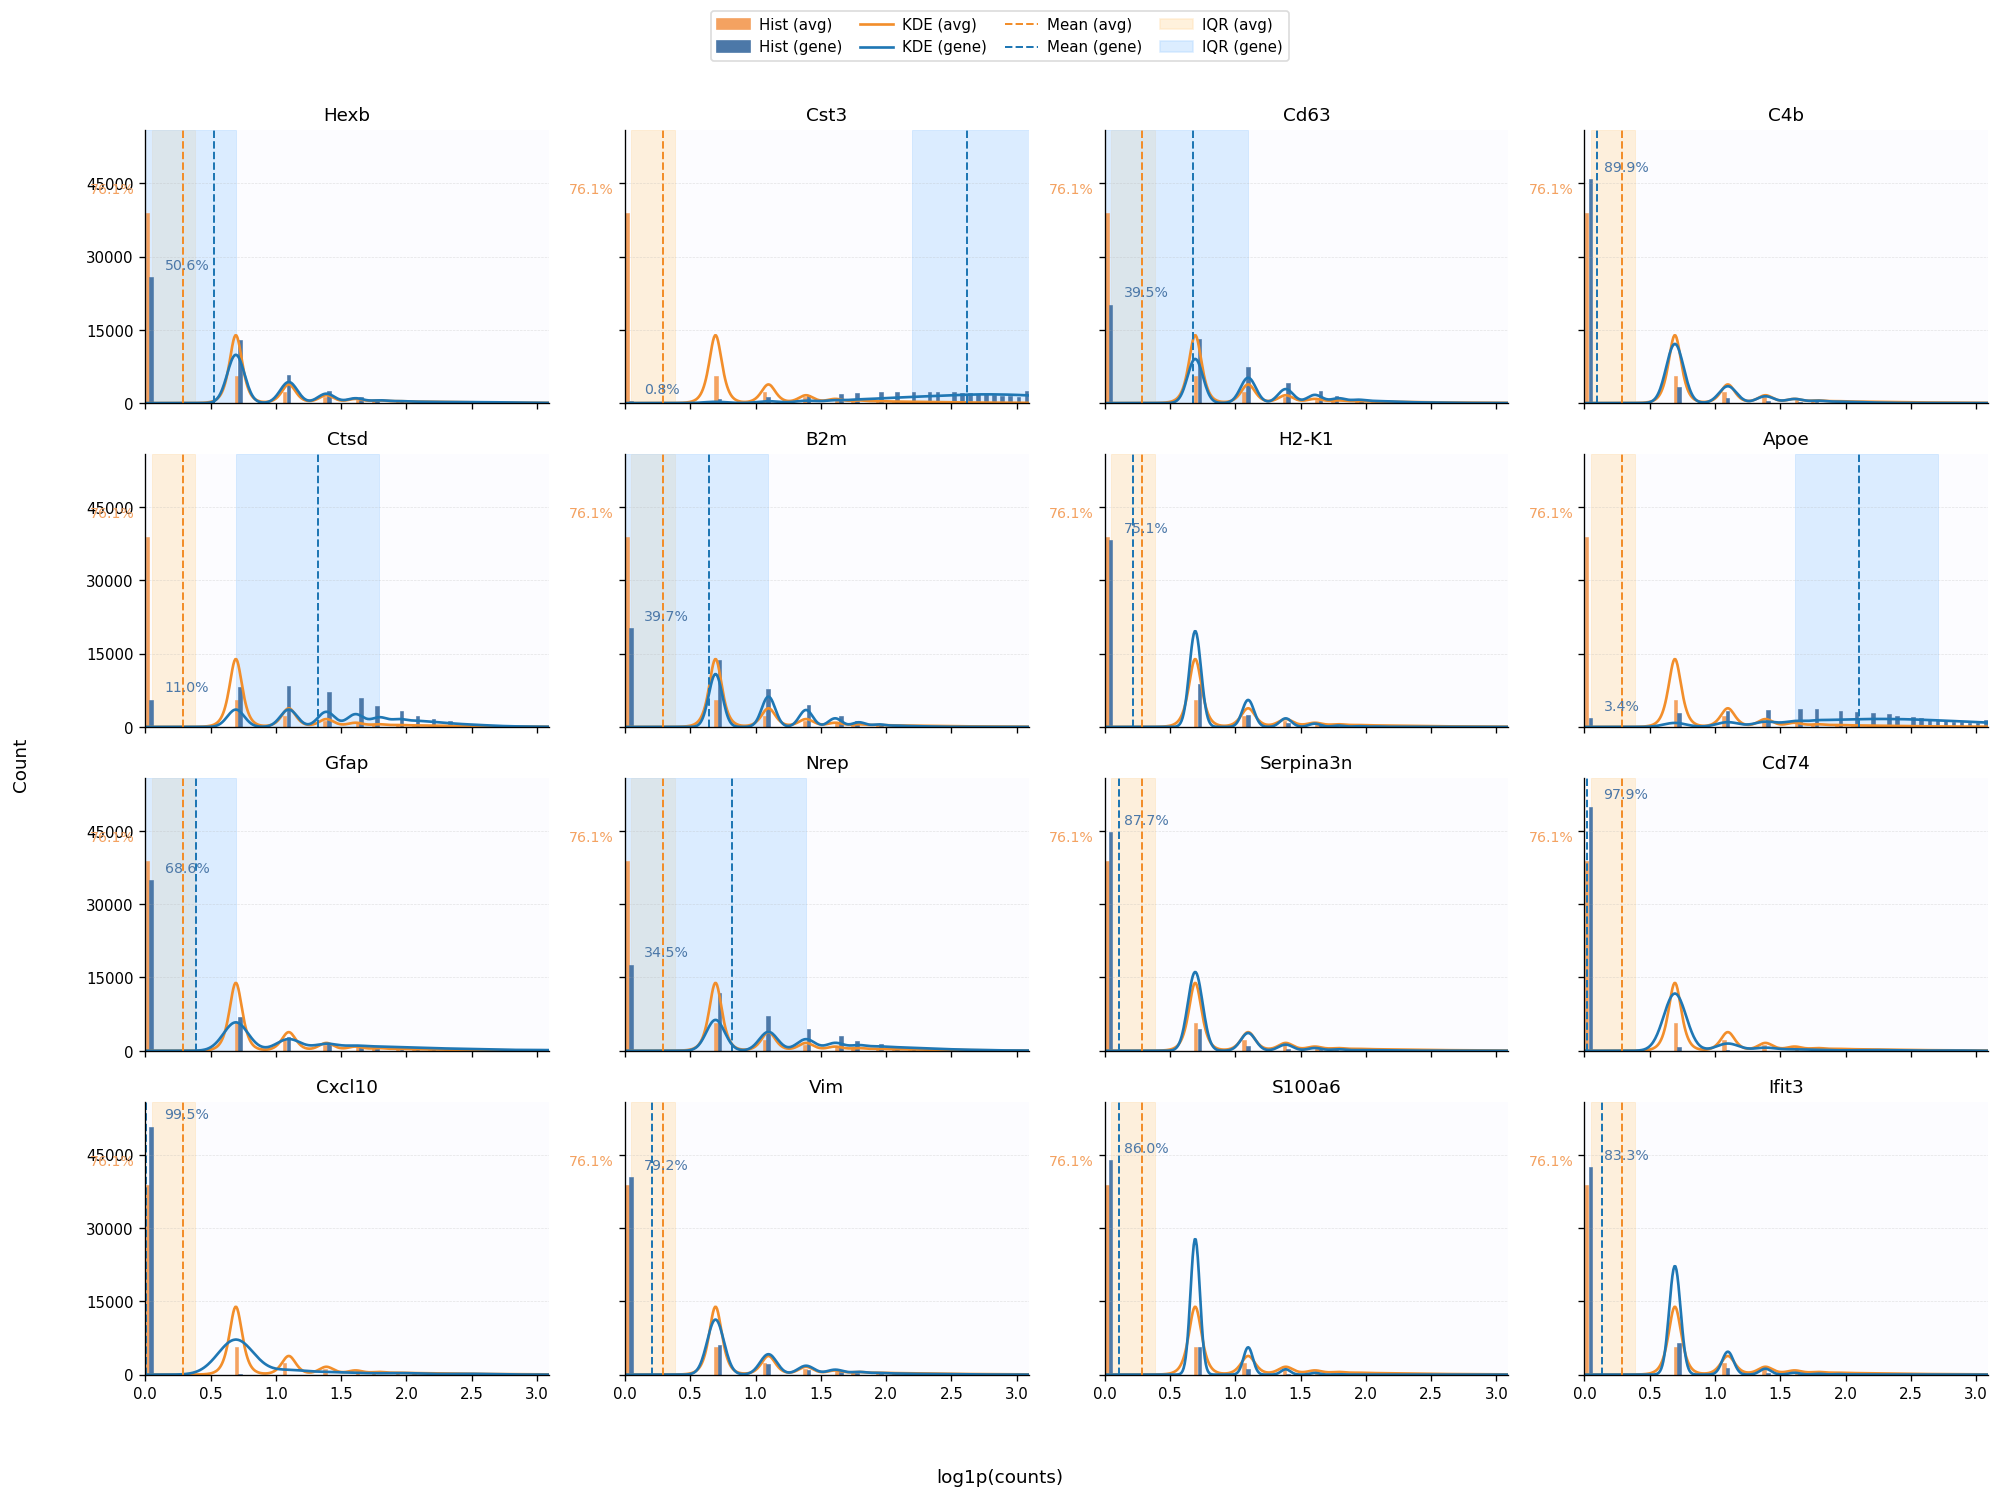

In [23]:
# 3. Plot the histogram + KDE for PIGs
pigs_z, info = compute_pigs_zscores(filtered_combined_df, gene_cols)
_ = plot_gene_distributions(filtered_combined_df, genes=info["present"], all_genes=gene_cols)

<a id="exp_anom"></a>
### 3.c. Anomaly detection framework

- We quantify unusualness of transcript counts by combining zero-inflation, dispersion, and shape statistics into a single score. 
- Namely, for each gene $g$ over $N$ cells, we compute five summary statistics:

    - Zero proportion: 
    $$
    \pi^{(= 0)}_g = 1 - \pi^{(\neq 0)}_g
    $$
    - Dispersion: 
    $$
    \mathrm{cv}_g = \dfrac{s_g}{\bar x_g + \varepsilon}
    $$
    - Shape: 
        - Skewness $\gamma_{1g}$
        - Kurtosis $\gamma_{2g}$
    - Tail ratio: $\mathrm{tail\_ratio}_g = \dfrac{q_{0.9}(X_g)+\varepsilon}{q_{0.1}(X_g)+\varepsilon}$

- We then z-normalize each of the five statistics, clip the results to $[-3, 3]$, and sum them to obtain the composite unusualness score for each gene $g$:
$$
\text{weird\_score}_g
= \sum_{k\in\{\text{zero\_frac},\ \text{cv},\ |\text{skew}|,\ \text{kurtosis},\ \text{tail\_ratio}\}}
\mathrm{clip}\bigl(Z_k(g), -3, 3\bigr).
$$

- The above calculation is performed on all 347 genes.
- The results of the following cell present:
    - Top 5 plaque-induced genes by the unusualness score $\text{weird\_score}_g$

##### Results & Discussion

- We find that among the 5 most unusual PIGs, Cxcl10 and Cd74 clearly stand out.
- Both have the weirdness score exceeding 8; the next highest is Serpina3n with a score an order of magnitude lower at 0.79.
- Looking at the diagnostic statistics above, we can see that both Cxcl10 and Cd74 have a very high zero proportion $\pi^{(= 0)}_g >0.97$

In [24]:
# For each gene, compute its unusualness based on zero-inflation, dispersion, and shape
S, Z = compute_weird_gene_scores(
    filtered_combined_df[gene_cols], clip_z=3.0, ddof_std=0, PIGs=info["present"]
)
logger.info(f"Genes evaluated: {len(S):,}")
logger.info("\nTop 5 PIGs by WEIRD SCORE")
display(
    S[S.index.isin(PIG_GENES)]
    .sort_values(by="weird_score", ascending=False)[["zero_frac", "weird_score"]]
    .head(5)
)

Genes evaluated: 347

Top 5 PIGs by WEIRD SCORE


,zero_frac,weird_score
Cxcl10,0.995158,9.352238
Cd74,0.979222,8.131972
Serpina3n,0.877137,0.788180
C4b,0.899130,0.194785
Gfap,0.686020,0.053448


## 4. **Exploratory Analysis of Plaque-to-Cell Distances**

<a id="viz_brain_regio"></a>
### 4.a. Visualize the brain regions by plaque proximity
- In this section, we will perform a visualization of how the Aβ-plaques are segmenting the brain tissue by distance to the nearest plaque.
- In the following code block, we highlight which brain regions are far away from Aβ-plaques and which are located nearby.
- We show this by overlaying the plaque polygons onto the morphology image.

##### Results & Discussion

- We can see that the maximum distance from any plaque is 457 µm; however, 99.07% of all cells are within 200 µm from a plaque.

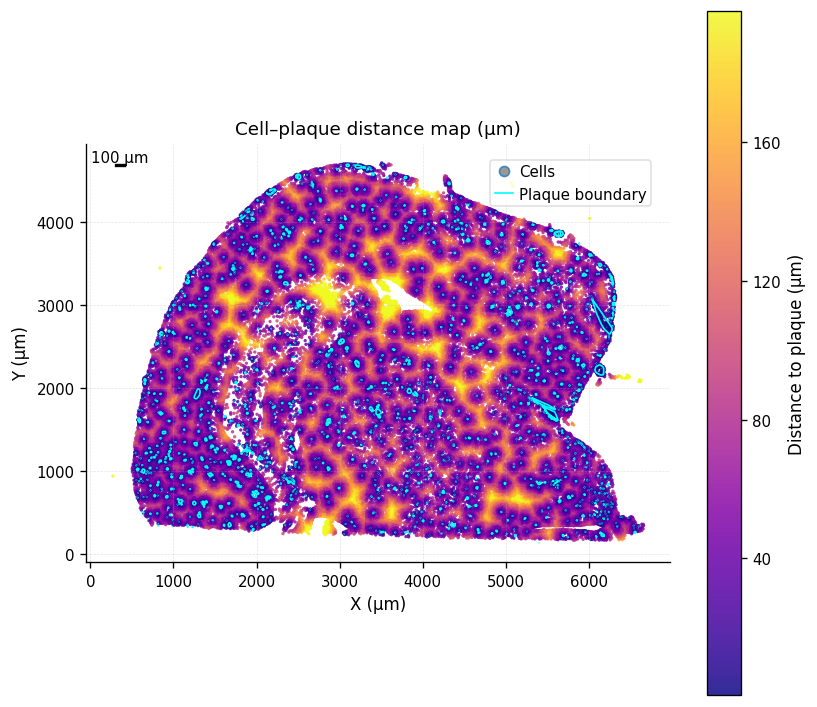

(<Figure size 840x720 with 2 Axes>,
 <Axes: title={'center': 'Cell–plaque distance map (µm)'}, xlabel='X (µm)', ylabel='Y (µm)'>)

In [25]:
plot_cell_to_plaque_map_visible(
    combined_df_normalized_full, gpd.GeoDataFrame({"geometry": plaques_poly["geometry"]})
)

In [26]:
median_dist = combined_df_normalized_full["distance_to_plaque"].median()
mean_dist = combined_df_normalized_full["distance_to_plaque"].mean()
logger.info(f"Median distance to nearest plaque: {median_dist:.2f} µm")
logger.info(f"Mean distance to nearest plaque: {mean_dist:.2f} µm")

Median distance to nearest plaque: 60.90 µm
Mean distance to nearest plaque: 68.01 µm


<a id="rq2_baseline"></a>
#### 4.b. How many cells are in each distance bin?

- Among the 53895 filtered cells, the average distance to the nearest plaque is 68.0 µm (median 60.9 µm).
- The standard deviation is very significant at 44.4 µm.
- This is supported by the previous figure showing the brain regions by distance to the nearest plaque - some regions are very close, and some are very far.
- Further, we can observe that the distribution of cell-to-plaque distances is right-skewed, with a long tail of infrequent cells which are very far from the nearest plaque.

=== Distance to nearest plaque (µm) summary ===
count    53895.000000
mean        68.011376
std         44.416354
min          0.000000
25%         34.454704
50%         60.899394
75%         93.897216
max        457.386841
Name: distance_to_plaque, dtype: float64


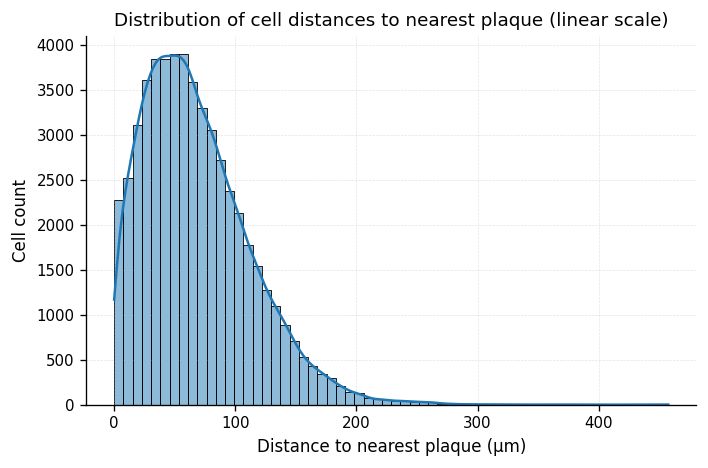

{'5%': 9.035547740783652, '25%': 34.4547036750835, '50% (median)': 60.89939421384185, '75%': 93.89721578622297, '95%': 149.8000085870341}

=== Cell counts by proximity class ===
dist_bin_simple
proximal (<30 µm)           11257
intermediate (30–100 µm)    31032
distal (>100 µm)            11606
Name: count, dtype: int64


In [27]:
results = analyze_plaque_distance(
    combined_df_normalized_full,
    column="distance_to_plaque",
)

## 5. **Research Questions**
<a id="rq1"></a>
### 5.a. How does PIG expression change in plaque proximity?

<a id="rq1_visual"></a>
#### 5.a.i. Visual analysis

##### Summary
- In this section, we investigate how the expression of the 16 PIGs changes with distance to the nearest plaque.
- To this end, we group the cells by distance to the nearest plaque into 5 bins.
- Further, we compute per-bin mean as well as a Standard Error for the mean (SEM) for all 16 PIGs.


##### Mathematical formulation

- We are working with the cells $i\in\{1,\dots,N\}$ and genes $g\in\mathcal{G}$, with $|\mathcal{G}|=347$.  
- Let $x_{ig}\ge 0$ denote the (log1p-normalized) transcript count of gene $g$ in cell $i$, and let $d_i\in\mathbb{R}_{\ge 0}$ be that cell’s distance to the nearest plaque.


##### Quantile binning of distances
- We fix the number of bins $m$ (in the following code block we reuse $m=5$ the same way it was done in all over the notebook).  
- Let $q_0<q_1<\dots<q_m$ be the empirical quantiles of the plaque-to-cell distances $\{d_i\}_{i=1}^N$.  
- We will work with the half-open bins formulated as follows
$$
B_b \;=\; [\,q_{b-1},\,q_b\,),\qquad b=1,\dots,m,
$$
- These bins define the bin assignment map which can be applied to any cell $i$:
$$
b(i)\;:\; d_i \in B_b,\quad b \in \{1,\dots,m\},
$$
- In per-gene analyses (e.g., ANOVA), the number of occupied bins for gene $g$ after NA-dropping is denoted $K_g$ and satisfies $K_g \le m$.

##### Mean expression per distance bin
- For each gene $g$ and bin $b$, we compute the mean normalized transcript count via:
$$
\mu_{g b}
\;=\;
\frac{1}{|I_b|}
\sum_{i\in I_b} x_{ig},
\qquad
I_b \;=\;\{\, i:\; b(i)=b \,\},
$$

- These mean normalized transcript counts $\mu_{g b}$ are plotted across binned plaque distance to show the spatial trends in gene expression.
- Further, we construct a 95% confidence interval for the mean expression within each bin.
- For each gene $g$ and distance bin $b$, let the set of cells be $I_{g,b}$ with size $n_{g,b}$ and log1p-normalized expression values $\{x_{ig}\}_{i\in I_{g,b}}$.
- The per-bin standard error of the mean (SEM) is given by:
$$
\mathrm{SEM}_{g b} \,=\, \frac{s_{g b}}{\sqrt{n_{g,b}}},\quad
s_{g b}^2 \,=\, \frac{1}{n_{g,b}-1}\sum_{i\in I_{g,b}} \bigl(x_{ig}-\bar x_{g b}\bigr)^2.
$$
- The plotted 95% CI band uses a normal approximation (central limit theorem) and is defined by:
$$
\bar x_{g b} \,\pm\, 1.96\,\mathrm{SEM}_{g b}.
$$


##### Ranking genes by spatial variation
- To examine which genes are most affected by the proximity of the Aβ-plaque, we define a spatial variation score $S_g$
- This score captures the variation across the closest and furthest distance bins
$$
S_g
\;=\;
\bigl|\mu_{g 1}-\mu_{g,5}\bigr|,
\qquad g\in\mathcal{G}.
$$
- We then sort the 16 PIGs by their spatial variation score.

##### Results & Discussion

- The results show that among the 16 PIGs, Gfap shows the strongest spatial variation, as its expression quickly decays as we move away from the plaque.
- This is supported by the Gfap's role as an intermediate filament protein found predominantly in astrocytes
- The visualization also highlights consistent decreasing gradients for microglial (e.g., Hexb, Ctsd, Cst3, Apoe) and astrocytic (e.g., Gfap, Serpina3n, Vim) markers.
- In other words, the brain regions most proximal to plaques (up to 29 µm) show elevated microglial (Hexb, Ctsd, Cst3, Apoe) and astrocytic (Gfap, Serpina3n, Vim) expression that fades with distance.

Assigning 5 quantile bins by distance_to_plaque
Computing mean expression per bin
Computing SEM per bin


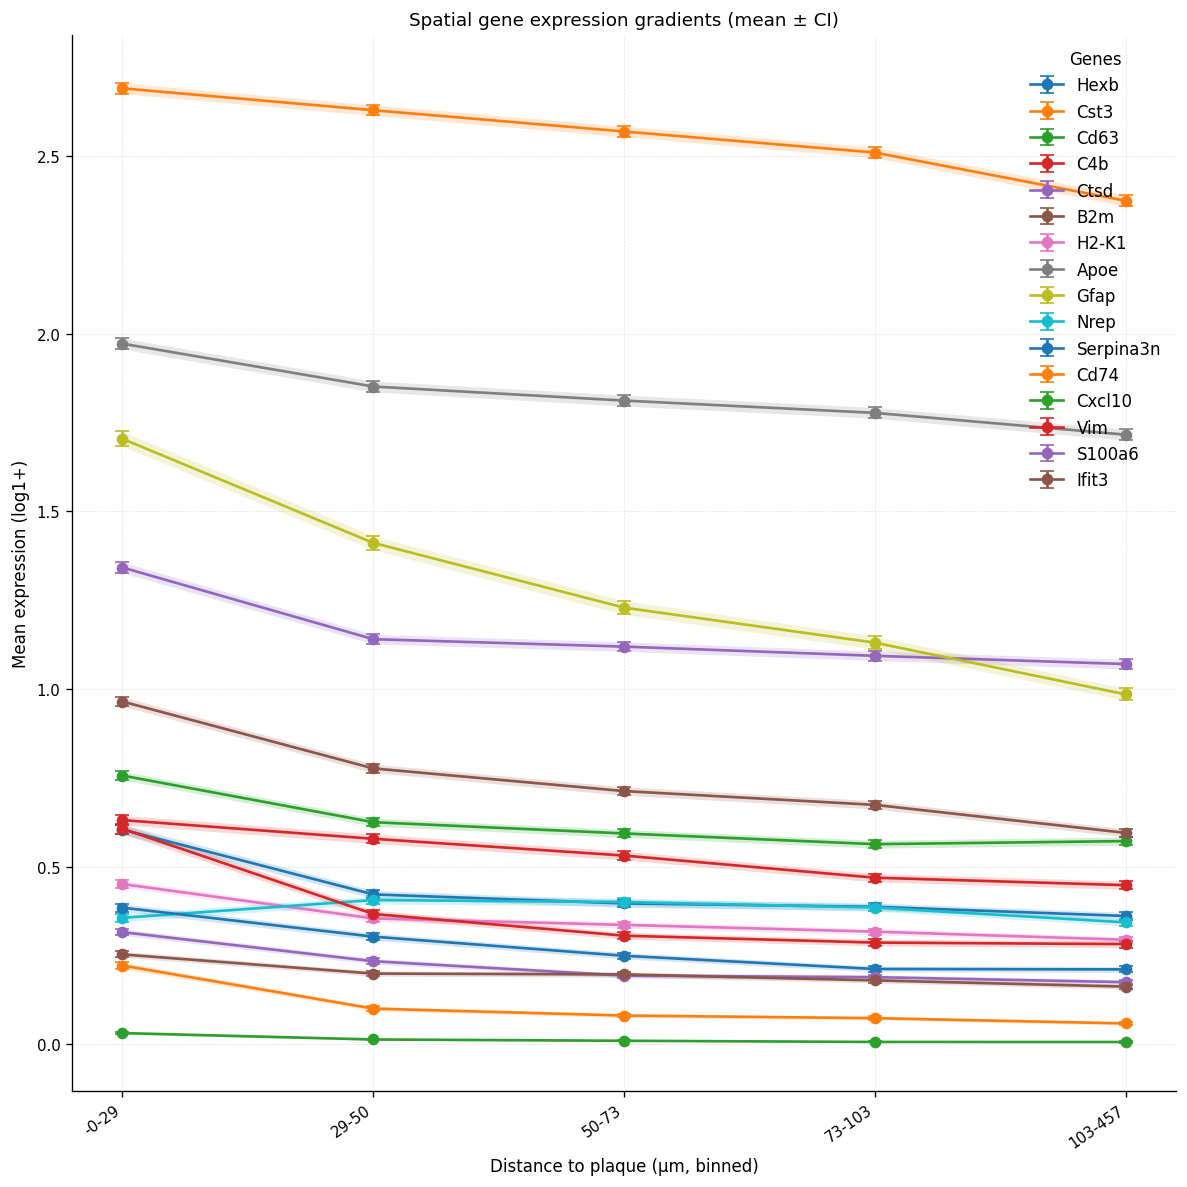

PIGs sorted by expression difference between closest and furthest distance bin


Gfap         0.719619
B2m          0.369777
Vim          0.324884
Cst3         0.316578
Ctsd         0.271888
Apoe         0.256267
Hexb         0.243458
Cd63         0.184586
C4b          0.183273
Serpina3n    0.173775
Cd74         0.163084
H2-K1        0.156954
S100a6       0.140852
Ifit3        0.090674
Cxcl10       0.025118
Nrep         0.012755
dtype: float64

In [88]:
combined_binned = assign_distance_bins(combined_df_normalized_full, n_bins=5)
mean_expr = mean_expression_by_bin(combined_binned, gene_cols)
sem_expr = sem_expression_by_bin(combined_binned, gene_cols)
# Plot trends for known PIG genes
plot_gene_trends(mean_expr, PIG_GENES, sem_expr=sem_expr, ci="95ci", figsize=(10, 10))

logger.info("PIGs sorted by expression difference between closest and furthest distance bin")
diff = mean_expr.iloc[0] - mean_expr.iloc[-1]
diff[diff.index.isin(PIG_GENES)].sort_values(ascending=False)

<a id="rq1_reg"></a>
#### 5.a.ii. Regression of PIG expression on plaque distance

##### Mathematical formulation

- For each $g \in \mathrm{PIGs}$, we fit an ordinary least squares (OLS) regression with an intercept:
$$
x_{ig} \;=\; \beta_{0g} + \beta_{1g}\,d_i + \varepsilon_{ig}, 
\qquad \varepsilon_{ig} \stackrel{\text{i.i.d.}}{\sim} \mathcal{N}(0,\sigma_g^2), 
\qquad i=1,\dots,N
$$
- Here, we have that:
    - $x_{ig}$ is the normalized transcript count in cell $i$ 
    - $d_i$ is the distance of cell $i$ to the nearest plaque in µm.

- We compute p-values associated with the null hypothesis $H_0:\ \beta_{1g}=0$ (no distance effect).
- We also perform multiple testing correction using the Benjamini–Hochberg FDR adjustment across the 16 PIGs.
- Since $x_{ig}$ are log-normalized counts, the slope $\beta_{1g}$ equals the change in log of transcript count per additional µm from the nearest plaque.
- The negative sign of the inferred coefficients ($\beta_{1g}<0$) implies higher gene expression around plaques.
- In other words, expression of PIGs decreases with distance. 
- Meanwhile, the intercept $\beta_{0g}$ equals the baseline log-expression at $d=0$, i.e., at the plaque surface.
- To transform the changes in log-expression to the original integer transcript count scale, we can use the fold-change formula:
- As we move $\Delta d$ microns away from the plaque, the fold-change in expected transcript count of gene $g$ is
$$
\text{Fold-change}_g(\Delta d) \;=\; \exp\!\big(\beta_{1g}\,\Delta d\big).
$$

##### Results & Discussion
- All 16 PIGs exhibit a statistically significant negative slope at 0.01 FDR level.
- However, the slopes vary significantly among PIGs, with the smallest and largest absolute values of slopes corresponding to Cxcl10 and Gfap, respectively.
- Gfap: 
    - $\beta_{1,\mathrm{Gfap}}\approx -5.41\times 10^{-3}$/µm.
    - Distance to halve expression:
    $$
    d_{1/2,g} \;=\; \frac{\ln 2}{|\beta_{1g}|} \;\approx\; \frac{0.693}{0.00541} \;\approx\; 128~\mu\mathrm{m}.
    $$
- Cxcl: 
    - $\beta_{1,\mathrm{Cxcl10}}\approx -1.57\times 10^{-4}$/µm.
    - Half-distance:
    $$
    d_{1/2,g}\approx \frac{0.693}{0.000157}\approx 4{,}415~\mu\mathrm{m}
    $$ 
    - This value exceeds the radius of the brain tissue, indicating that for Cxcl10, the spatial trend is very weak.



In [29]:
reg_df, proximal_genes = regress_expression_vs_distance(
    combined_df_normalized_full, PIG_GENES, logger=logger
)
logger.info("Continuous regression results (expression ~ distance):")
display(reg_df)

# Highlight top plaque-proximal genes (negative slope)
proximal_genes = reg_df[reg_df["slope"] < 0].sort_values("qval").head(10)
logger.info("\nTop plaque-proximal genes (negative slope, smallest q-values):")
display(proximal_genes)

Continuous regression results (expression ~ distance).
Computed 16 gene regressions.
Top plaque-proximal genes (negative slope, smallest q-values): 10 returned.
Continuous regression results (expression ~ distance):


,gene,slope,pval,qval
8,Gfap,-0.005408,0.000000e+00,0.000000e+00
5,B2m,-0.002597,0.000000e+00,0.000000e+00
1,Cst3,-0.002562,6.287627e-240,2.515051e-239
13,Vim,-0.001964,2.713979e-261,1.447455e-260
7,Apoe,-0.001763,1.218245e-109,1.949192e-109
0,Hexb,-0.001622,2.067871e-165,5.514323e-165
4,Ctsd,-0.001556,7.925067e-105,1.152737e-104
3,C4b,-0.001445,5.028431e-112,1.005686e-111
10,Serpina3n,-0.001202,6.635228e-139,1.516624e-138
11,Cd74,-0.001027,1.634044e-209,5.228941e-209



Top plaque-proximal genes (negative slope, smallest q-values):


,gene,slope,pval,qval
8,Gfap,-0.005408,0.000000e+00,0.000000e+00
5,B2m,-0.002597,0.000000e+00,0.000000e+00
13,Vim,-0.001964,2.713979e-261,1.447455e-260
1,Cst3,-0.002562,6.287627e-240,2.515051e-239
11,Cd74,-0.001027,1.634044e-209,5.228941e-209
0,Hexb,-0.001622,2.067871e-165,5.514323e-165
10,Serpina3n,-0.001202,6.635228e-139,1.516624e-138
3,C4b,-0.001445,5.028431e-112,1.005686e-111
14,S100a6,-0.000885,3.523692e-110,6.264341e-110
7,Apoe,-0.001763,1.218245e-109,1.949192e-109


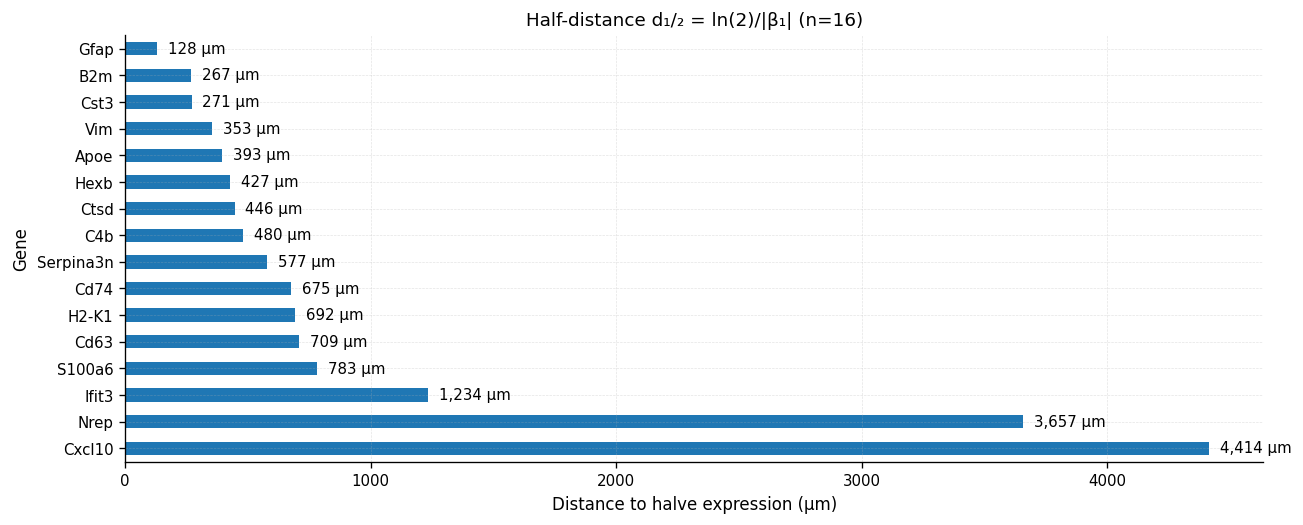

In [30]:
ax, plot_df = plot_half_distance(
    reg_df,
    gene_col="gene",
    slope_col="slope",
    qval_col="qval",
    filter_negative=True,
    sort="half",
    top_n=None,  # or e.g., 30
    log_scale=False,
    tissue_radius_um=None,  # e.g., 2000
    annotate=True,
)
plt.show()

<a id="rq1_anova"></a>
#### 5.a.iii. ANOVA-style analysis of PIG expression in different distance bins

##### Mathematical formulation

- For each $g \in \mathrm{PIGs}$, let $b_i \in \{1,\dots,K_g\}$ denote the distance-bin label for cell $i$ and $x_{ig}$ its normalized expression. 
- Note that here $K_g\leq m$
- In general, $K_g$ may be less than $m$ since for some genes, the cells with positive transcript counts may occur only in a subset of bins.
- We fit a one-way ANOVA with a categorical factor for `distance_bin` (i.e., $b_i$ for cell $i$):
- The normalized transcript count of cell $i$ is modeled as some random noise $\varepsilon_{ig}$ around the mean $\mu_{g, b_i}$ expression level of the host bin $b_i$
$$
x_{ig} \,=\, \mu_{g, b_i} + \varepsilon_{ig}, \qquad \varepsilon_{ig} \stackrel{\mathrm{i.i.d.}}{\sim} \mathcal{N}(0,\sigma_g^2).
$$
- To fit an ordinary least squares regression, we use treatment (dummy) coding of the distance bins with baseline bin $b=1$ being the closest-to-plaque bin.
- Overall, we will have $K_g-1$ indicators (excluding the baseline bin $b=1$).
- We then model the difference in expression compared to the baseline bin $b=1$ as
$$
x_{ig} \,=\, \alpha_{g0} + \sum_{k=2}^{K_g} \alpha_{gk}\,\mathbf{1}\{b_i = k\} + \varepsilon_{ig},
$$
with the mapping $\mu_{g1}=\alpha_{g0}$ and $\mu_{gk}=\alpha_{g0}+\alpha_{gk}$ for $k\ge2$.
- Each coefficient $\alpha_{gk}$ ($k\ge 2$) measures how the mean in bin $k$ differs from the baseline bin $b=1$. 
- Thus, $\alpha_{gk}>0$ indicates higher mean expression than at the plaque surface, and $\alpha_{gk}<0$ indicates lower.
- Overall, the ANOVA model allows for a distinct mean $\mu_{g b}$ for each distance bin $b$.
- The statistical testing then analyzes whether these bin-specific means differ.
- Concretely, we compute the p-value associated with the following null hypothesis:
  $$
  H_0:\ \mu_{g1}=\mu_{g2}=\cdots=\mu_{gK_g}\quad
  $$
- The test statistic follows $F_{K_g-1,\ n_g-K_g}$ under $H_0$.
- Here $n_g$ is the number of non-missing observations for gene $g$.
- For the above F-distribution to be defined, we need to have at least two distinct groups ($K_g\ge 2$).
- If this criterion is not met, we set the p-value to `NaN`.
- P-values across genes are adjusted with Benjamini–Hochberg FDR (discussed above) to obtain q-values.

##### Results & Discussion

- Among the 16 PIGs, all 16 show significant differences in mean expression across distance bins at FDR $=0.01$ (ANOVA q-values). 
- For now, we will inspect the per-bin means for a specific PIG, Gfap, to illustrate the results.
- Per-bin means decrease monotonically from the closest bin to the farthest;
- Compared to the baseline bin ($b=1$), difference in the average normalized transcript count ranges from -0.720 to −0.293.
- This difference is about two orders of magnitude larger than the Standard Error of the Mean (SEM) which is on the scale of 0.01 thanks to a large $n=10779$ per bin. 
- This confirms a higher Gfap expression around the plaques and a strong decay with distance.


In [31]:
anova_df = compute_genewise_categorical_anova(combined_binned, PIG_GENES)
logger.info("Categorical ANOVA results (expression ~ distance_bin):")
logger.info(
    f"Found {int((anova_df['qval'] < signif_level).sum())} genes with significant differences in mean expression across distance bins at FDR={signif_level}"
)
display(anova_df)

gene_to_inspect = "Gfap"
g_means = compute_group_means_for_gene(combined_binned, gene_to_inspect, group_col="distance_bin")
# Differences relative to the baseline (first bin)
baseline_label = g_means["index"].iloc[0]
baseline_mean = float(g_means["mean_expr"].iloc[0])
g_means["delta_vs_baseline"] = g_means["mean_expr"] - baseline_mean
logger.info(f"Per-bin means for {gene_to_inspect} (baseline = {baseline_label}):")
display(g_means)

Categorical ANOVA results (expression ~ distance_bin):
Found 16 genes with significant differences in mean expression across distance bins at FDR=0.01


,gene,anova_pval,qval
0,B2m,0.000000e+00,0.000000e+00
1,Gfap,0.000000e+00,0.000000e+00
2,Cd74,0.000000e+00,0.000000e+00
3,Vim,0.000000e+00,0.000000e+00
4,Hexb,1.111715e-238,3.557487e-238
5,Cst3,8.305159e-214,2.214709e-213
6,Serpina3n,6.228163e-205,1.423580e-204
7,Ctsd,5.412445e-203,1.082489e-202
8,S100a6,4.170606e-181,7.414411e-181
9,Cd63,2.009742e-152,3.215588e-152


Per-bin means for Gfap (baseline = (-0.001, 28.98]):


,index,mean_expr,sem_expr,n,delta_vs_baseline
0,"(-0.001, 28.98]",1.704359,0.010556,10779,0.000000
1,"(28.98, 50.315]",1.411382,0.009895,10779,-0.292977
2,"(50.315, 72.638]",1.228991,0.009648,10779,-0.475368
3,"(72.638, 102.91]",1.130328,0.009256,10779,-0.574031
4,"(102.91, 457.387]",0.984740,0.008494,10779,-0.719619


- Next, we look at top 5 and bottom 5 genes by most negative slopes and smallest FDR-adjusted q-values
- Looking at the results, we can see that Gfap once again shows the strongest trend in expression decay with distance.
- Meanwhile, Cd63 shows the weakest trend as it has the smallest absolute value of the slope.
- Further, we can see that the extremely zero-inflated Cxcl10 also is among the bottom 5 genes.
- This is because its expression is very low across distance bins with a weak absolute value of bin-to-bin difference.

In [32]:
summary_stats, top_df, bottom_df = summarize_gene_stats(reg_df, anova_df, logger=logger)

=== Top plaque-proximal genes (negative slope, smallest q-values) ===
   gene     slope  pval_continuous  qval_continuous     anova_pval  \
0  Gfap -0.005408     0.000000e+00     0.000000e+00   0.000000e+00   
1   B2m -0.002597     0.000000e+00     0.000000e+00   0.000000e+00   
2  Cst3 -0.002562    6.287627e-240    2.515051e-239  8.305159e-214   
3   Vim -0.001964    2.713979e-261    1.447455e-260   0.000000e+00   
4  Apoe -0.001763    1.218245e-109    1.949192e-109  4.255101e-127   

      qval_anova  
0   0.000000e+00  
1   0.000000e+00  
2  2.214709e-213  
3   0.000000e+00  
4  5.673468e-127  

=== Least plaque-responsive genes (weakest or flat slopes) ===
      gene     slope  pval_continuous  qval_continuous     anova_pval  \
11    Cd63 -0.000977     3.424795e-60     4.215133e-60  2.009742e-152   
12  S100a6 -0.000885    3.523692e-110    6.264341e-110  4.170606e-181   
13   Ifit3 -0.000562     1.533243e-47     1.752278e-47   2.610652e-66   
14    Nrep -0.000190     4.693449e-04  

<a id="rq2"></a>
### 5.b. How does cell type composition change in plaque proximity?

- In this section, we will we will explore clustering of cells based on the 347-dimensional gene expression vector.
- Further, we will quantify changes in the clustering-based cell type frequency near plaques.

<a id="rq2_cell"></a>
#### 5.b.i. Joint cell clustering and analysis 

#### Mathematical formulation

##### Data
- Let $X\in\mathbb{R}^{N\times |\mathcal{G}|}$ be the gene expression matrix with log-normalized transcript counts for each cell.
- In our dataset, we have that $|\mathcal{G}|=347$ and $N=53895$.
- For each cell $i\in\{1,\dots,N\}$ we denote the distance to the nearest plaque $d_i\in\mathbb{R}_{\ge 0}$ measured in µm.

##### Dimensionality reduction with Principal Component Analysis (PCA)
- We begin by centering and scaling columns of $X$ to obtain $\tilde X$.
- Next, we compute the Singular Value Decomposition (SVD) of $\tilde X$:
$$
\tilde X = U\,\Sigma\,V^\top
\quad\text{with singular values }\sigma_1 \ge \cdots \ge \sigma_r \ge 0\text{ on the diagonal of }\Sigma.
$$

- We then identify 30 leading principal component directions (PCs).
- PCs are given by the columns $v_1,\dots,v_{30}$ of $V$ corresponding to the largest singular values $\sigma_1,\dots,\sigma_{30}$.
- Next, we project gene-expression vectors of cells onto these 30 PCs:
$$
Y \;=\; \tilde X\,V_{[:,1:30]} \;=\; U_{[:,1:30]}\,\Sigma_{1:30,1:30}\;\in\;\mathbb{R}^{N\times 30} \quad\text{by orthonormality of columns of $V$}.
$$


##### Leiden clustering
- Building on the dimensionality-reduced vectors, we will create a $k$-nearest-neighbor graph (here $k=15$).
- This graph is specified by a weighted, symmetric adjacency matrix $A\in\mathbb{R}_{\ge 0}^{N\times N}$ specified in the Principal Component space $Y$.
- Let us denote:
$$
\mathrm{deg}_i=\sum_j A_{ij}.
$$
$$
2w=\sum_{i,j}A_{ij}.
$$
- We will use the adjacency matrix $A$ as input to the Leiden clustering algorithm.
- This algorithm comes up with a partition $\mathcal{C}=\{C_1,\dots,C_K\}$ maximizing the following reward function:
$$
Q_\gamma(\mathcal{C})
:=\frac{1}{2w}\sum_{i,j}\Big(A_{ij}-\gamma\,\frac{\mathrm{deg}_i\,\mathrm{deg}_j}{2w}\Big)\,\mathbf{1}\{c_i=c_j\} \text{ where } \gamma=0.6 \text{ and label $c_i\in\{1,\dots,K\}$ denotes the exclusive cluster of cell $i$.}
$$
- Namely, we seek the partition $\hat{\mathcal{C}}$ that maximizes the reward function $Q_\gamma(\mathcal{C})$:
$$
\hat{\mathcal{C}}\in\arg\max_{\mathcal{C}}\;Q_\gamma(\mathcal{C}),\qquad
$$
- The reward function encourages the learned groups $\hat{\mathcal{C}}$ to be composed of nodes that are more connected to each other than expected by chance. 

##### Logistic regression of cluster membership vs. distance
- We will use logistic regression to model the relationship between cluster membership (as defined by the indicator $Z_{ik}=\mathbf{1}\{c_i=k\}$ for each cell $i\in\{1,\dots,N\}$ and cluster $k\in\{1,\dots,K\}$) and distance to the nearest plaque $d_i$.
- Specifically, we fit the following logistic regression model:
$$
\Pr(Z_{ik}=1\mid d_i)=\sigma\big(\alpha_k+\beta_k\, d_i\big),\qquad \sigma(t)=\frac{1}{1+e^{-t}}.
$$
- Here $\alpha_k$ is the baseline log-odds at $d_i=0$, and $\beta_k$ is the change in log-odds per additional 100 µm.
- For a probability $p\in(0,1)$ we define the odds as $p/(1-p)$ and the log-odds as $\log\!\big(p/(1-p)\big)$. 
- Our logistic regression models the log-odds as a straight line depending on $d_i$.
- Given a learned coefficient $\beta_k$, the logistic regression can predict the change in probability of being in cluster $k$ over a certain distance.
- For instance, over 100 µm, the change in log-odds is $100\,\beta_k$.
- To translate this back into the change in the odds between $d+100$ and $d$, we exponentiate the change in log-odds:
  $$
  \mathrm{OR}_{100} \;=\; \frac{\mathrm{odds}(d+100)}{\mathrm{odds}(d)}
  \;=\; \frac{e^{\alpha_k+\beta_k(d+100)}}{e^{\alpha_k+\beta_k d}}
  \;=\; e^{100\,\beta_k}.
  $$
- If $\beta_k>0$, and correspondingly $\mathrm{OR}_{100}>1$, odds increase; if $\beta_k<0$, and correspondingly $\mathrm{OR}_{100}<1$, odds decrease.
- Additionally, as part of logistic regression, we test the null hypotheses:
$$
H_{0,k}:\beta_k=0\quad\text{for all }k\in\{1,\dots,K\}.
$$
- We obtain the p-values $p_k$ for each null hypothesis $H_{0,k}$ (for cluster $k$) and apply Bonferroni correction over the $K$ tested clusters:
$$
p_k^{\mathrm{adj}}=\min\{K\,p_k,\,1\}.
$$

##### Gene expression by cluster
- Given the set of measured genes $\mathcal{G}$ and the mean expression $\mu_{kg}$ of gene $g$ in cluster $k$, we can compute the per-gene summary statistics as well as the z‑score matrix:
$$
\bar\mu_g=\frac{1}{K}\sum_{k=1}^K \mu_{kg},\qquad
\sigma_g=\sqrt{\frac{1}{K}\sum_{k=1}^K(\mu_{kg}-\bar\mu_g)^2},\qquad
z_{kg}=(\mu_{kg}-\bar\mu_g)/\sigma_g
$$
- Using the above z-score matrix, we can find out which cluster is associated with the highest expression of the gene $g$:
$$
k^\star(g)=\arg\max_{k\in\{1,\dots,K\}} z_{kg}.
$$

#### Results & Discussion 
##### Leiden clustering
- In our run, we obtained $K=19$ clusters.
- Superimposing the color-coded clusters onto the brain tissue, we can see that the gene expression-based clustering strongly correlates with the brain morphology.
- Cluster 6 (i.e., vascular cells) is almost exclusively localized to the outer rim of the brain, corresponding to epidural space.
- Hippocampal formation shows a distinct cluster 14 which follows the elongated shape of the dentate gyrus.
- Looking at the inferred cell type, we can confirm that cluster 14 corresponds to Dentate gyrus immature neurons (glutamatergic)
- Meanwhile, the region hosting amygdala and hypothalamus is dominated by cluster 10.
- Cluster 10 corresponds to Hypothalamic medial mammillary glutamatergic neurons, matching its observed localization.
- The ventricle cavities are lined with distinct cluster of cells (ID 15).
- This cluster corresponds to Hypothalamic GnRH1-expressing glutamatergic neurons.
- This finding is expected since hypothalamus forms the floor and part of the lateral walls of the third ventricle.

##### Gene expression per cluster
- Looking at the marker gene enrichment diagram, we can see that some clusters are characterized by a strong over- or under-expression of specific genes.
- For instance, cluster 8 (immune cells) is characterized by a strong over-expression of the gene Hexb 
- The z-score is around 4, indicating that the expression of Hexb in cluster with ID 8 is at impressive 4 standard deviations above the mean.
- Meanwhile, cluster 14 (Dentate gyrus immature glutamatergic neurons) is characterized by a strong under-expression of the gene Cst3, which happens to be at around 2 standard deviations below the mean.
- This pattern highlights the fact that the morphological structure of the brain is closely related to the gene expression patterns.

##### Cluster ID v.s. distance
- Next, we can discuss the figure presenting the relationship between the cluster frequency and the binned distance to the nearest plaque.
- We can clearly see an upward trend in the frequency of the members of clusters 0 (Oligodendrocyte precursor cells / oligodendrocytes) as we move away from the plaque.
- For other clusters, the frequency only changes at extreme distances.
- For instance, cluster 15 (Hypothalamic GnRH1-expressing glutamatergic neurons) shows a steep increase in proportion only after 113 µm.
- Meanwhile, cluster 14 (Dentate gyrus immature glutamatergic neurons) shows a steep decline after 138 µm.
- As for the short distances, cluster 8 (immune cells) shows a sharp drop as we move past the first bin; however the decay quickly levels off.

##### Logistic regression coefficients

- Let us now discuss and interpret some notable coefficients.
- We will compare the following:
  - The baseline probability of seeing a cluster $k$ at the plaque surface 
  $$
  p_k(0)=\sigma(\alpha_k)
  $$
  - The probability of seeing this cluster at a distance of $d=100$ from the plaque:
  $$
  p_k(100)=\sigma(\alpha_k+100\,\beta_k)
  $$
  - Relative change is computed as:
  $$
  \frac{p(100)-p(0)}{p(0)}\times 100\%.
  $$

Proximal-enriched (negative slopes; adjusted $p\ll 0.01$)

| Cluster | Slope $\beta_k$ | $p(0)$ | $p(100)$ | Relative change |
|:------:|-----------------:|-------:|---------:|----------------:|
| Immune | −0.01427 | 0.159 | 0.043 | −72.7% |
| Vascular | −0.01116 | 0.100 | 0.035 | −64.9% |
| Pons, Gluta | −0.00772 | 0.015 | 0.007 | −53.4% |
| Intra/Extratelencephalic, Gluta | −0.00361 | 0.075 | 0.054 | −28.7% |
| Cortex medial, GABA | −0.00282 | 0.041 | 0.031 | −23.8% |
| Astrocyte | −0.00114 | 0.136 | 0.123 | −9.5% |

Distal-enriched (positive slopes; adjusted $p\ll 0.01$)

| Cluster | Slope $\beta_k$ | $p(0)$ | $p(100)$ | Relative change |
|:------:|-----------------:|-------:|---------:|----------------:|
| Hypothalamic Gnrh1, Gluta | +0.02346 | 0.002 | 0.019 | +927.0% |
| Medulla, GABA | +0.01815 | 0.002 | 0.012 | +508.2% |
| Cerebral LGE, GABA | +0.00781 | 0.016 | 0.035 | +114.3% |
| Olfactory bulb, Gluta | +0.00678 | 0.011 | 0.021 | +94.9% |
| Dentate, Gluta | +0.00591 | 0.014 | 0.025 | +78.5% |
| Corticothalamic, Gluta | +0.00384 | 0.029 | 0.042 | +44.8% |
| Hypothalamic medial, Gluta | +0.00256 | 0.033 | 0.042 | +27.9% |
| Oligodendrocyte | +0.00208 | 0.161 | 0.191 | +18.7% |


- The regression analysis reveals the changes in cell composition with a varying distance to the nearest plaque.
- The table reveals that the proportion of most neural cells is strongly depleted around the plaque.
- On the contrary, astrocytes, vascular and immune cell subtypes are highly enriched in the nearest distance bin.
- This agrees well with the known mechanisms of Alzheimer's progression
- Existing findings reveal that amyloid plaque environment are inducing neuronal degeneration, pathological astrocytic and microglial activation, and vascular remodeling.
- In the above table, the relationship between the frequency and distance form plaque is especially strong for Hypothalamic GnRH1-expressing glutamatergic neurons.
- For this cluster, the frequency increases by around 10 times as we move away from the plaque by 100 µm.
- Inspecting the overlayed clusters on brain tissue, we can see that cells from this cluster predominantly occur inside the ventricle cavities.
- This makes them trivially distant from the plaque. 
- These cells are surrounded by cerebrospinal fluid, a clear liquid devoid of amyloid beta plaques.
- The amyloid beta plaques are instead scattered throughout the solid brain tissue, explaining the steep increase in frequency for Cluster 21 at larger distances.
- However, our table also reveals a surprising finding: some neurons (namely, intratelencephalic–Extratelencephalic glutamatergic neurons, Pons glutamatergic neurons, and Cortex–medial ganglionic eminence GABAergic neurons) seem to be enriched close to plaques.
- We suspect that this could be due to the fact that these neurons could be somewhat more resilient to the plaque-induced damage. Thus, they die, but a lower rate compared to the other neurons.
##### Feasibility Notes
- End‑to‑end runtime finishes in under 5 minutes.


- Please uncomment the cell below if you are running this notebook for the first time
- The cell below will take 30 minutes to run (Macbook Pro M4)

In [33]:
# Joint Leiden clustering across mice (global/comparable clusters)
# Desired order reflects the time axis. We use wt-13 (not wt-17) as only wt-13 is available.
# mouse_order = ["tg-2", "tg-5", "tg-17", "wt-2", "wt-5", "wt-13"]
# available_mouse_order = [m for m in mouse_order if m in preprocessed_datasets]

# # Build a mapping from mouse_id -> normalized_counts dataframe
# joint_input = {m: preprocessed_datasets[m]["normalized_counts"] for m in available_mouse_order}

# joint_res = cluster_cells_leiden_joint(
#     joint_input,
#     leiden_resolution=0.6,
#     n_neighbors=15,
#     n_pcs=30,
#     logger=logger,
# )

# adata_by_mouse_joint = joint_res.adata_by_mouse
# clustered_df_by_mouse_joint = joint_res.df_by_mouse

# logger.info(
#     "Completed joint Leiden clustering for mice: %s",
#     ", ".join(available_mouse_order),
# )

# Save the joint and independent clustering
# with open("src/data/clustering.pkl", "wb") as f:
#     pickle.dump({
#         'joint_res': joint_res,
#         'adata_by_mouse_joint': adata_by_mouse_joint,
#         'clustered_df_by_mouse_joint': clustered_df_by_mouse_joint,
#         'adata_by_mouse': adata_by_mouse,
#         'available_mouse_order': available_mouse_order,
#         'df_clustered_by_mouse': df_clustered_by_mouse,
#         'clustering_results_by_mouse': clustering_results_by_mouse,
#     }, f)

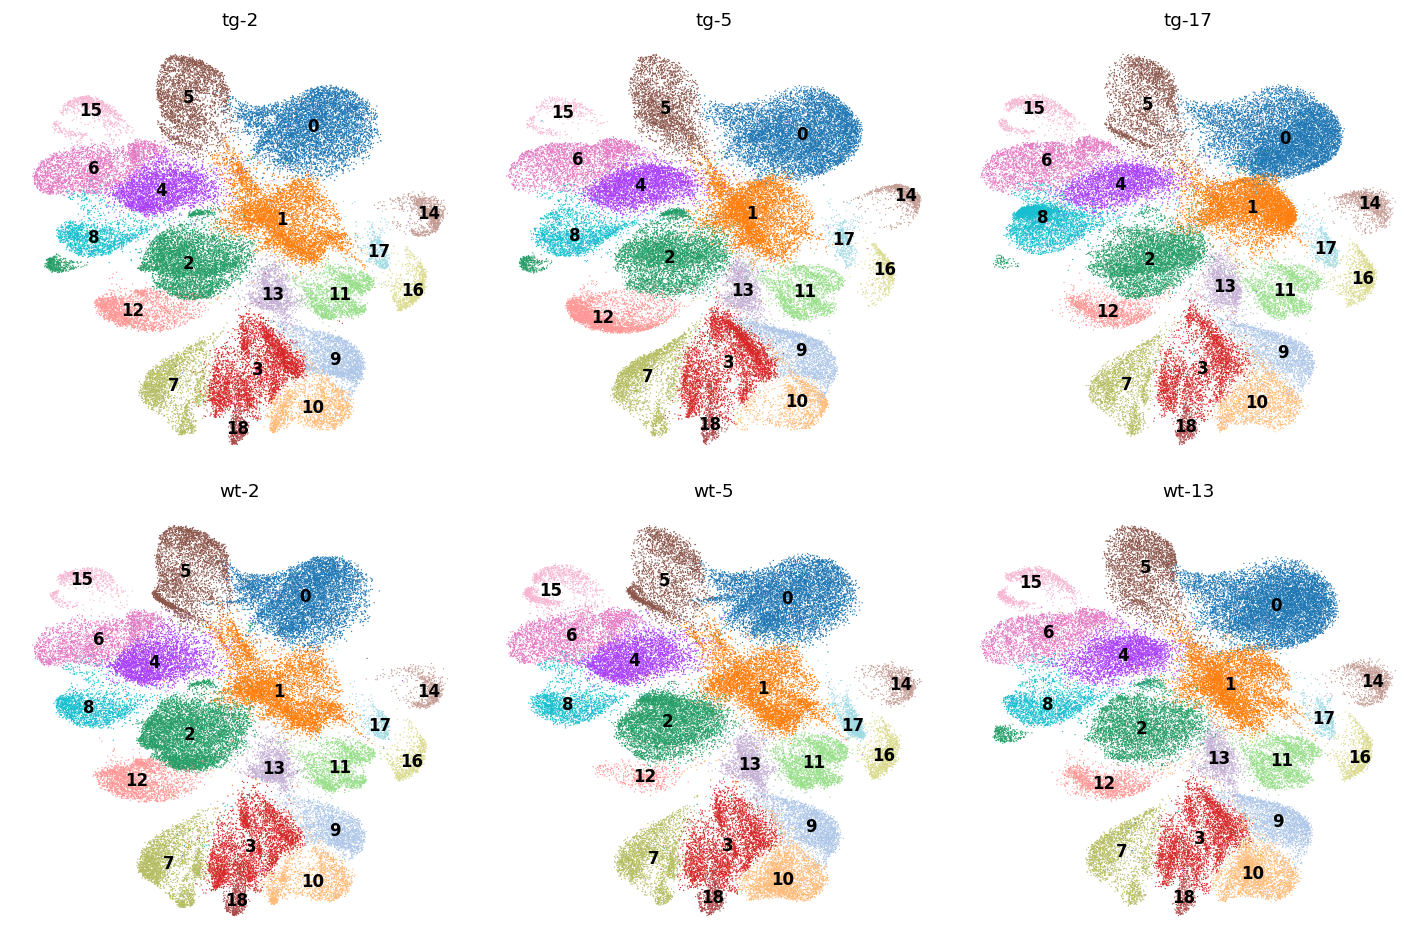

In [34]:
with open("src/data/clustering.pkl", "rb") as f:
    data = pickle.load(f)
    joint_res = data["joint_res"]
    adata_by_mouse_joint = data["adata_by_mouse_joint"]
    clustered_df_by_mouse_joint = data["clustered_df_by_mouse_joint"]
    adata_by_mouse = data["adata_by_mouse"]
    available_mouse_order = data["available_mouse_order"]
    df_clustered_by_mouse = data["df_clustered_by_mouse"]
    clustering_results_by_mouse = data["clustering_results_by_mouse"]

# 2x3 UMAP grid of joint Leiden clusters (comparable across mice)
plot_leiden_umap_grid(
    adata_by_mouse_joint,
    available_mouse_order,
    n_cols=3,
    figsize=(12, 8),
    legend_loc="on data",
    suptitle="",
)

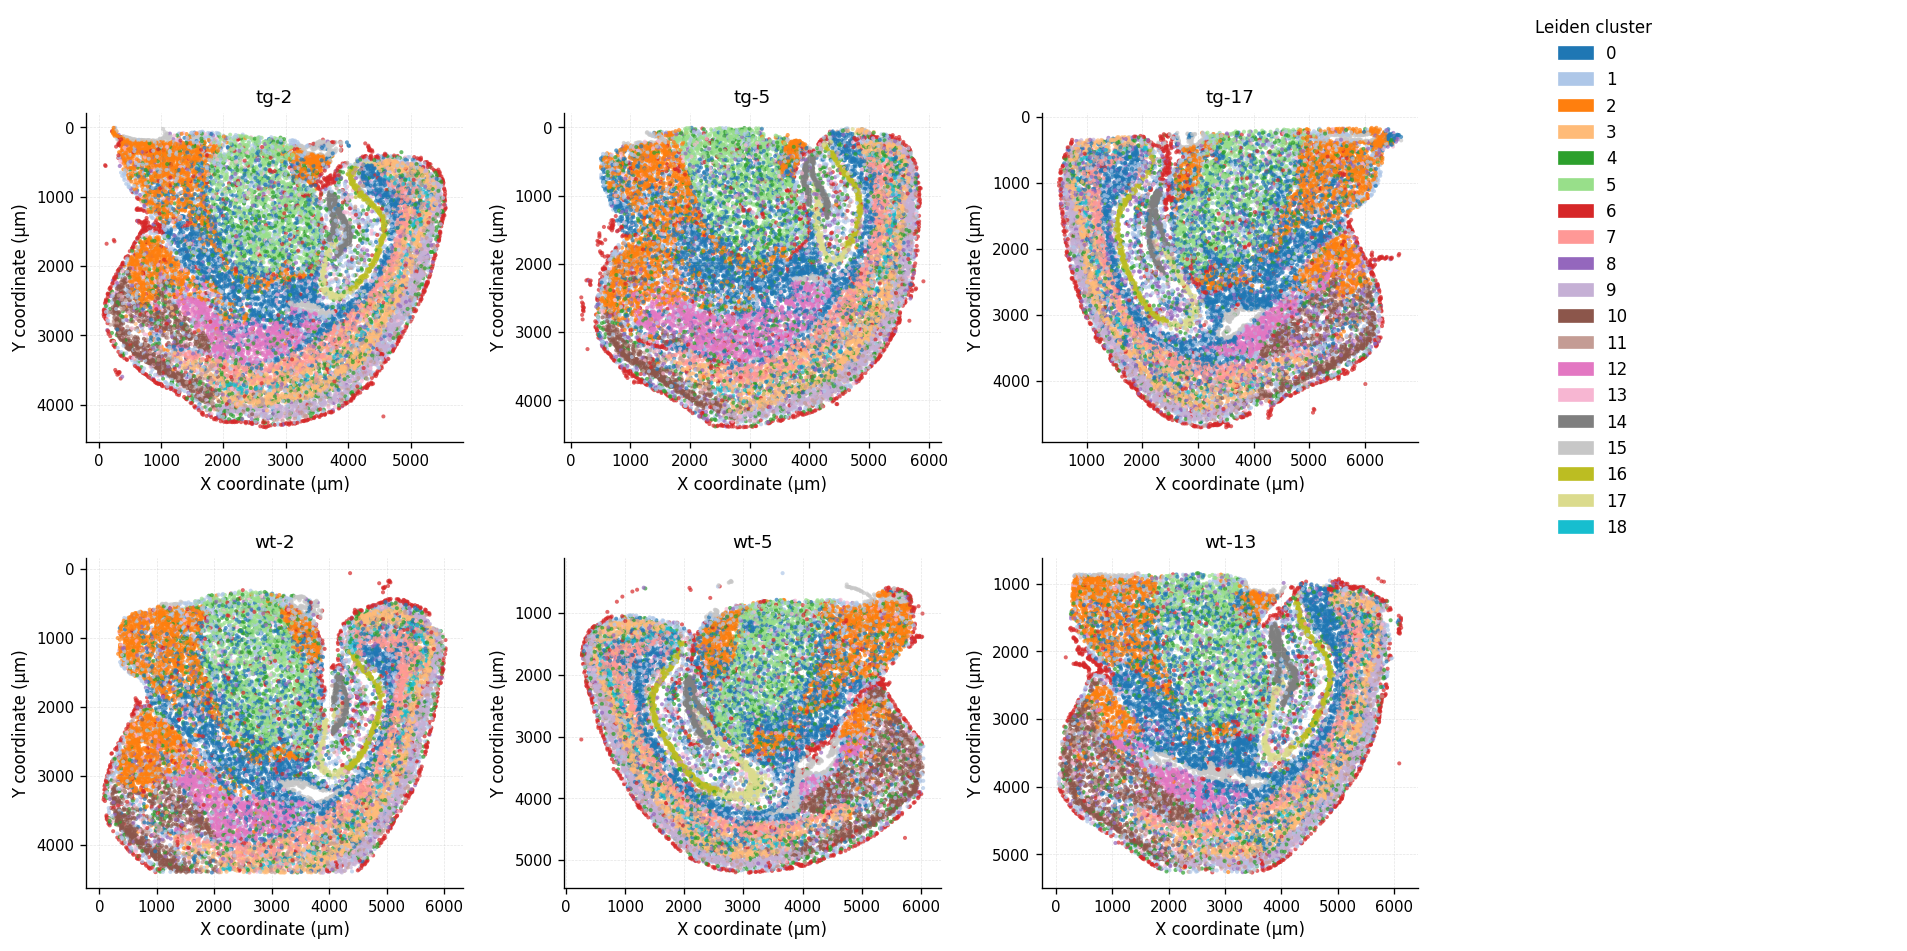

In [52]:
# 2x3 spatial grid of joint Leiden clusters (comparable across mice)
plot_leiden_spatial_grid(
    clustered_df_by_mouse_joint,
    available_mouse_order,
    n_cols=3,
    figsize=(12, 8),
    sample_for_scatter=20_000,
    random_state=0,
    suptitle="",
)

In [36]:
# Save joint (global) cluster-augmented tables per mouse
# Files are saved with `_with_global_clusters_{mouse}.csv` suffixes.
for mouse_age in available_mouse_order:
    logger.info(
        "Saving joint cluster-augmented tables for %s",
        mouse_age,
    )
    clusters = clustered_df_by_mouse_joint[mouse_age][["cell_id", "cluster_leiden"]]
    folder = xenium_config[mouse_age]["data_folder"]

    # Join cluster id to normalized and preprocessed counts
    norm = preprocessed_datasets[mouse_age]["normalized_counts"].merge(
        clusters, on="cell_id", how="inner"
    )
    pre = preprocessed_datasets[mouse_age]["preprocessed_counts"].merge(
        clusters, on="cell_id", how="inner"
    )

    norm_out = f"{folder}/normalized_counts_with_global_clusters_{mouse_age}.csv"
    pre_out = f"{folder}/preprocessed_counts_with_global_clusters_{mouse_age}.csv"

    logger.info(
        "Shapes of dataframes:\n" f"Normalized: {norm.shape}\n" f"Preprocessed: {pre.shape}"
    )

    norm.to_csv(norm_out, index=False)
    pre.to_csv(pre_out, index=False)

    logger.info(
        "Saved joint clustered outputs for %s to:\n - %s\n - %s",
        mouse_age,
        norm_out,
        pre_out,
    )

Saving joint cluster-augmented tables for tg-2
Shapes of dataframes:
Normalized: (47862, 358)
Preprocessed: (47862, 359)
Saved joint clustered outputs for tg-2 to:
 - src/data/Xenium_V1_FFPE_TgCRND8_2_5_months/normalized_counts_with_global_clusters_tg-2.csv
 - src/data/Xenium_V1_FFPE_TgCRND8_2_5_months/preprocessed_counts_with_global_clusters_tg-2.csv
Saving joint cluster-augmented tables for tg-5
Shapes of dataframes:
Normalized: (52008, 358)
Preprocessed: (52008, 359)
Saved joint clustered outputs for tg-5 to:
 - src/data/Xenium_V1_FFPE_TgCRND8_5_7_months/normalized_counts_with_global_clusters_tg-5.csv
 - src/data/Xenium_V1_FFPE_TgCRND8_5_7_months/preprocessed_counts_with_global_clusters_tg-5.csv
Saving joint cluster-augmented tables for tg-17
Shapes of dataframes:
Normalized: (53895, 358)
Preprocessed: (53895, 359)
Saved joint clustered outputs for tg-17 to:
 - src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/normalized_counts_with_global_clusters_tg-17.csv
 - src/data/Xenium_V1_FFPE_TgC

In [37]:
preprocessed_global_clusters_tg_17 = pd.read_csv(
    "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/preprocessed_counts_with_global_clusters_tg-17.csv"
)
normalized_global_clusters_tg_17 = pd.read_csv(
    "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/normalized_counts_with_global_clusters_tg-17.csv"
)
columns_to_add = [
    c
    for c in combined_df_normalized_full.columns
    if c not in preprocessed_global_clusters_tg_17.columns
    or c not in normalized_global_clusters_tg_17.columns
]
preprocessed_global_clusters_tg_17_with_plaque_data = preprocessed_global_clusters_tg_17.merge(
    combined_df_normalized_full[["cell_id", *columns_to_add]],
    on="cell_id",
    how="inner",  # or 'inner', depending on what you want
)
normalized_global_clusters_tg_17_with_plaque_data = normalized_global_clusters_tg_17.merge(
    combined_df_normalized_full[["cell_id", *columns_to_add]],
    on="cell_id",
    how="inner",  # or 'inner', depending on what you want
)
logger.info(
    f"After merging, the shape of the normalizeddataframe is: {preprocessed_global_clusters_tg_17_with_plaque_data.shape}"
)
logger.info(
    f"After merging, the shape of the raw counts dataframe is: {preprocessed_global_clusters_tg_17_with_plaque_data.shape}"
)
normalized_global_clusters_tg_17_with_plaque_data.to_csv(
    "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/normalized_counts_with_global_clusters_tg-17_with_plaque_data.csv",
    index=False,
)
preprocessed_global_clusters_tg_17_with_plaque_data.to_csv(
    "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/preprocessed_counts_with_global_clusters_tg-17_with_plaque_data.csv",
    index=False,
)

After merging, the shape of the normalizeddataframe is: (53895, 365)
After merging, the shape of the raw counts dataframe is: (53895, 365)


In [38]:
# Define mappings
tissue_map = {
    "tg-2": "Xenium_V1_FFPE_TgCRND8_2_5_months_outs",
    "tg-5": "Xenium_V1_FFPE_TgCRND8_5_7_months_outs",
    "tg-17": "Xenium_V1_FFPE_TgCRND8_17_9_months_outs",
    "wt-2": "Xenium_V1_FFPE_WtCRND8_2_5_months_outs",
    "wt-5": "Xenium_V1_FFPE_WtCRND8_5_7_months_outs",
    "wt-13": "Xenium_V1_FFPE_WtCRND8_13_4_months_outs",
}

type_to_expanded_type = {
    "OEC": "Olfactory ensheathing",
    "Astro-Epen": "Astrocyte",
    "CNU-HYa Glut": "Hypothalamic GABA",
    "IT-ET Glut": "Intra/Extratelencephalic, Gluta",
    "CB GABA": "Cerebellar, GABA",
    "TH Glut": "Thalamic, Gluta",
    "Vascular": "Vascular",
    "NP-CT-L6b Glut": "Corticothalamic, Gluta",
    "Immune": "Immune",
    "CTX-CGE GABA": "Cortex caudal, GABA",
    "HY MM Glut": "Hypothalamic medial, Gluta",
    "CTX-MGE GABA": "Cortex medial, GABA",
    "CNU-LGE GABA": "Cerebral LGE, GABA",
    "Pineal Glut": "Pineal, Gluta",
    "DG-IMN Glut": "Dentate, Gluta",
    "HY Gnrh1 Glut": "Hypothalamic Gnrh1, Gluta",
    "OB-CR Glut": "Olfactory bulb, Gluta",
    "MY GABA": "Medulla, GABA",
    "P Glut": "Pons, Gluta",
}

# Run evaluation
results = evaluate_cluster_alignment(
    clustered_df_by_mouse_joint=clustered_df_by_mouse_joint,
    available_mouse_order=available_mouse_order,
    instructor_csv_path="src/data/Alzeimer_xenium_predicted_cell_types_with_ids.csv",
    tissue_map=tissue_map,
    type_to_expanded_type=type_to_expanded_type,
)
expanded_types = results["my_label_to_type"]
expanded_types[0] = "Oligodendrocyte"
expanded_types

{0: 'Oligodendrocyte',
 1: 'Astrocyte',
 2: 'Hypothalamic GABA',
 3: 'Intra/Extratelencephalic, Gluta',
 4: 'Cerebellar, GABA',
 5: 'Thalamic, Gluta',
 6: 'Vascular',
 7: 'Corticothalamic, Gluta',
 8: 'Immune',
 9: 'Cortex caudal, GABA',
 10: 'Hypothalamic medial, Gluta',
 11: 'Cortex medial, GABA',
 12: 'Cerebral LGE, GABA',
 13: 'Pineal, Gluta',
 14: 'Dentate, Gluta',
 15: 'Hypothalamic Gnrh1, Gluta',
 16: 'Olfactory bulb, Gluta',
 17: 'Medulla, GABA',
 18: 'Pons, Gluta'}

In [39]:
# Find second best match for cluster 0
# pairs, label_to_type = results["pairs"], results["label_to_type"]
# pairs[pairs["my_cluster"] == 0].sort_values("f1", ascending=False)
# label_to_type

Detected 347 gene columns
Using pre-existing cluster labels from column 'cluster_leiden'.
Cluster counts:
cluster_leiden
0     9776
1     6867
2     5659
8     4113
4     3325
3     3262
6     2909
5     2759
9     2110
10    2096
7     2053
11    1843
12    1556
13    1523
14    1153
16     938
15     917
17     537
18     499
Name: count, dtype: int64


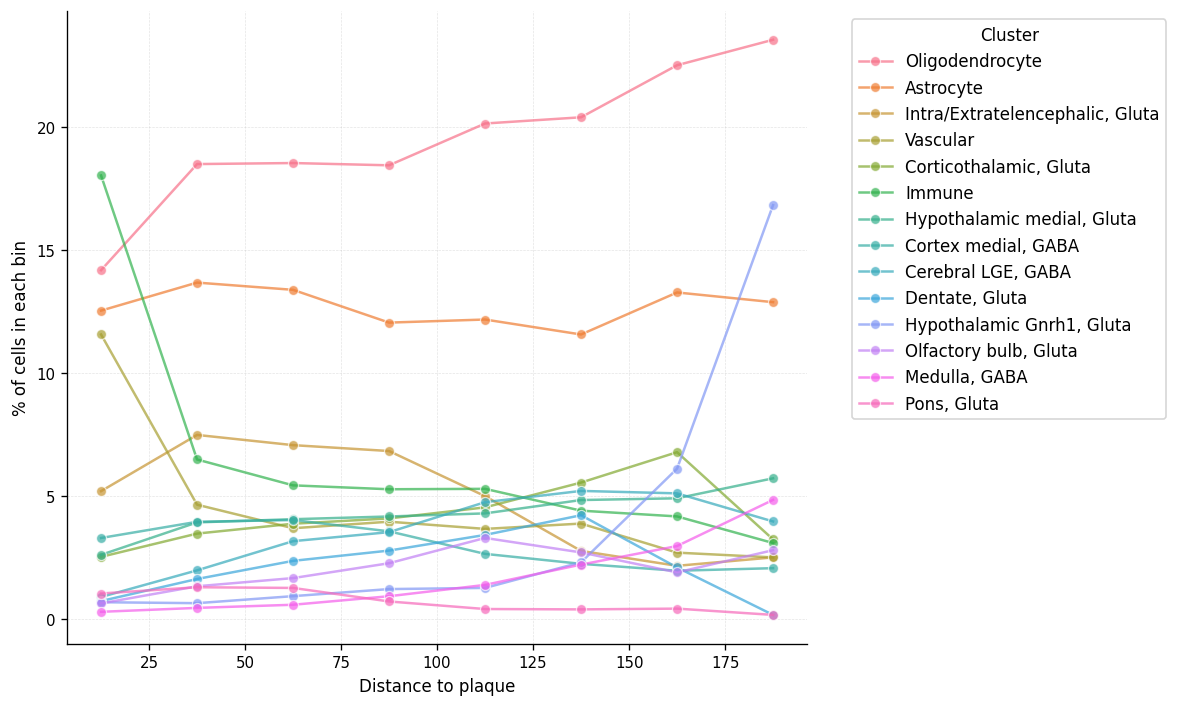

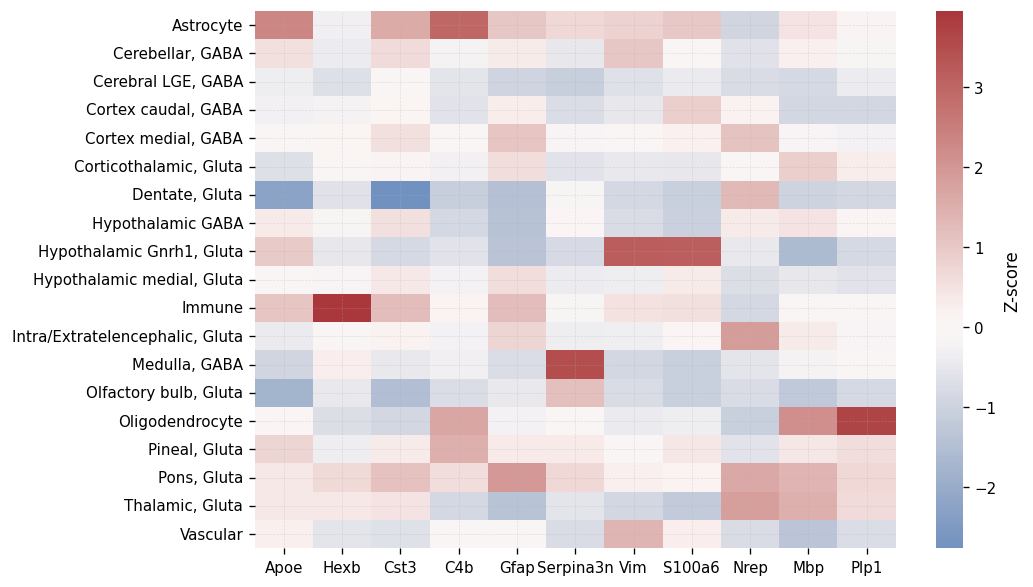


Logistic regression coefficients (in_cluster ~ distance_to_plaque):


,cluster,intercept,slope,se_intercept,se_slope,z_slope,pval,ci95_lo_slope,ci95_hi_slope,adj_pval
0,15,-6.316549,0.023461,0.082231,0.000590,39.743685,0.000000e+00,0.022304,0.024618,0.000000e+00
1,8,-1.669389,-0.014269,0.028464,0.000474,-30.076593,9.806804e-199,-0.015198,-0.013339,1.863293e-197
2,17,-6.241827,0.018153,0.093119,0.000704,25.798164,9.297900e-147,0.016773,0.019532,1.766601e-145
3,6,-2.201213,-0.011161,0.033432,0.000529,-21.092141,9.391407e-99,-0.012199,-0.010124,1.784367e-97
4,12,-4.109524,0.007813,0.049133,0.000494,15.830830,1.906876e-56,0.006845,0.008780,3.623065e-55
5,16,-4.542359,0.006776,0.062266,0.000637,10.629908,2.163253e-26,0.005527,0.008026,4.110180e-25
6,14,-4.260351,0.005906,0.056063,0.000589,10.019069,1.256817e-23,0.004750,0.007061,2.387953e-22
7,0,-1.650824,0.002075,0.020620,0.000245,8.461791,2.633030e-17,0.001595,0.002556,5.002756e-16
8,3,-2.507465,-0.003612,0.032536,0.000436,-8.293477,1.099856e-16,-0.004466,-0.002759,2.089727e-15
9,7,-3.504207,0.003841,0.041955,0.000469,8.192795,2.552284e-16,0.002922,0.004760,4.849340e-15


In [40]:
leiden_results = analyze_leiden_spatial(
    normalized_global_clusters_tg_17_with_plaque_data,
    logger=logger,
    plot=True,
    expanded_types=expanded_types,
)
# Display logistic regression coefficients: in_cluster ~ distance_to_plaque
logger.info("\nLogistic regression coefficients (in_cluster ~ distance_to_plaque):")
display(leiden_results.logit_df.sort_values("adj_pval", ascending=True).reset_index(drop=True))

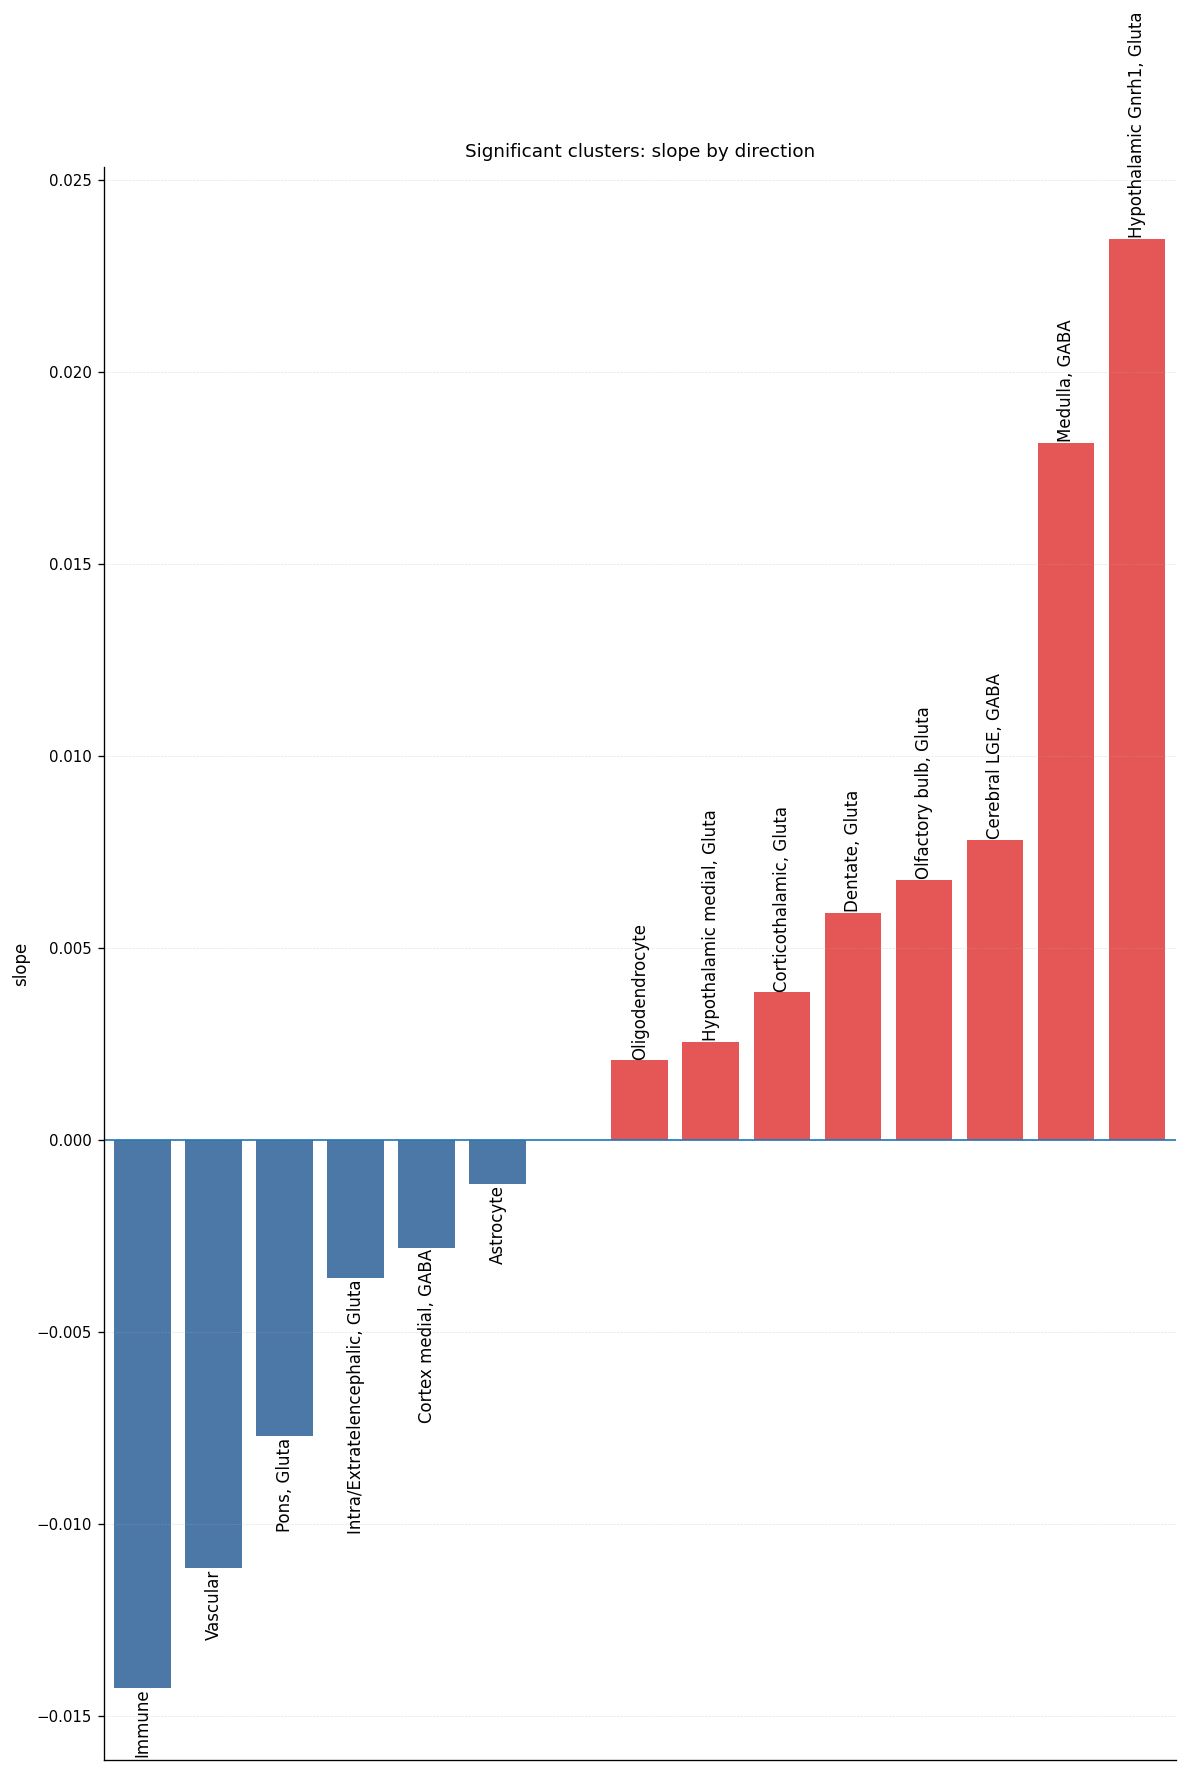

In [41]:
# using your existing object
fig, ax, sig_df = plot_leiden_logit_slopes(
    leiden_results.logit_df,
    expanded_types,
    cluster_col="cluster",  # adjust if needed
    pval_threshold=0.01,
    fig_height=15,
    ypad_scale=0.001,
    title="Significant clusters: slope by direction",
)

<a id="rq3"></a>
#### 5.c. Relationship between cell type composition, PIG expression, and plaque distance

<a id="rq3_corr"></a>
#### 5.c.i Correlation matrix between cell type composition and PIG expression

- In this section we will analyze cell-type proportions and PIG expression across distance.
- Our goal is to see if cell type composition can explain the changes in PIG expression.
- This could reveal a potential mechanism of how the amyloid beta plaques exert their influence on the gene expression in the surrounding area.
- In other words, we want to see if plaques change gene expression patterns by selectively killing some cells while sparing or even recruiting others.
- Having observed a strong relationship between the cell type proportions and the distance to the nearest plaque, we want to test whether PIG expression changes could be due to the changes in cell composition.
- To this end, we compute a Spearman rank correlation matrix between the cell type proportions and the average PIG expression, aligned on the same distance bins.
- We choose Spearman over Pearson because we suspect that the nature of the relationship is non-linear. 
- For instance, some cells can be "mega-expressing" a given PIG only when grouped together; this could result in a step-like pattern, favoring a more flexible Spearman.
- Further, we perform a Spearman test with a multiple testing correction to obtain a p-value for each gene–cell-type pair.

##### Mathematical formulation

- Let the distance to plaque be partitioned into $m$ ordered quantile-based bins: 
$$
\{B_b\}_{b=1}^m
$$ 
- We can define the distance-to-bin map $b(i)\in\{1,\dots,m\}$ so that $d_i\in B_{b(i)}$.
- For each PIG gene $g$ and bin $b$, we can compute the mean expression of that gene in that bin as
$$
\mu_{g b} \;=\; \frac{1}{|I_b|}\sum_{i\in I_b} x_{ig},\qquad I_b \;=\; \{\, i : b(i)=b \,\}.
$$
- Further, for each cell type $c$ and bin $b$, we calculate its proportion in that bin as
$$
\pi_{c b} \;=\; \frac{\#\{\, i\in I_b : c_i = c \,\}}{|I_b|} \;\in [0,1].
$$
- Next, we will compute a Spearman rank correlation between the mean expression of each PIG gene in a given bin and the cell type composition in the same bin, for all bins.
- We will use an ordered index $\{B_b\}_{b=1}^m$ ensuring that $\forall i \in \{1,\dots,m\}$ the $i$-th element of the gene expression vector $(\mu_{g1},\dots,\mu_{g m})$ and the $i$-th element of the cell type composition vector $(\pi_{c1},\dots,\pi_{c m})$ are corresponding to the same bin. 
- Finally, for each gene–cell-type pair $(g,c)$, we compute a Spearman rank correlation across bins:
  $$
  \rho_{g c} \;=\; \operatorname{corr}\!\big(\operatorname{rank}(\mu_{g1:m}),\; \operatorname{rank}(\pi_{c1:m})\big),
  $$
- Subsequently, we use the Spearman test to obtain the p-values $p_{g c}$.
- We then apply a Benjamini–Hochberg (BH) correction on top of $p_{g c}$ to obtain the q-values $q_{g c}$. 
- In this analysis, we set the significance threshold to $q_{g c}<0.01$.

##### Results and discussion

- As a result, we found 9 cell types showing significant Spearman rank correlations with PIG expression.
- However, they differ by which PIGs they are correlated with.
- 8 out of 9 cell types are strongly correlated with the core 14 PIGs:
    - Hexb 
    - Cst3 
    - C4b 
    - Ctsd 
    - B2m 
    - H2-K1 
    - Apoe 
    - Gfap
    - Serpina3n 
    - Cd74 
    - Cxcl10 
    - Vim 
    - S100a6 
    - Ifit3
- 1 out of 9 cell types are strongly correlated with the single-PIG:
    - Nrep
- Overall, the 14 core PIGs are overexpressed in the immune cells.
- They are underexpressed in most neuronal cell types.
- Meanwhile, the Nrep gene complements the above 14 PIGs in the sense that the Intratelencephalic–Extratelencephalic glutamatergic cell type that is correlated with it is unrelated to any other PIG.
- The following tables present the exact cell types, their roles, and which PIGs they are correlated with in detail.

##### Cell types vs. PIG expression

| Cell type (ID & label) | Description (expanded name) | Sign | $\rho_{gc}$ | PIG genes involved |
|---|---|---:|---:|---|
| 07 — “Corticothalamic, Gluta” | Near-projecting corticothalamic layer 6b glutamatergic neurons | Negative | $-1.00$ | Core 14 PIGs |
| 08 — “Immune” | Immune cells (microglia, macrophages, etc.) | Positive | $+1.00$ | Core 14 PIGs |
| 10 — “Hypothalamic medial, Gluta” | Hypothalamic medial mammillary glutamatergic neurons | Negative | $-1.00$ | Core 14 PIGs |
| 12 — “Cerebral LGE, GABA” | Cerebral nuclei LGE-derived GABAergic neurons | Negative | $-1.00$ | Core 14 PIGs |
| 14 — “Dentate, Gluta” | Dentate gyrus immature neurons (glutamatergic) | Negative | $-1.00$ | Core 14 PIGs |
| 15 — “Hypothalamic Gnrh1, Gluta” | Hypothalamic GnRH1-expressing glutamatergic neurons | Negative | $-1.00$ | Core 14 PIGs |
| 16 — “Olfactory bulb, Gluta” | Olfactory bulb Cajal–Retzius glutamatergic neurons | Negative | $-1.00$ | Core 14 PIGs |
| 17 — “Medulla, GABA” | Medulla GABAergic neurons | Negative | $-1.00$ | Core 14 PIGs |
| 03 — “Intra/Extratelencephalic, Gluta” | Intratelencephalic–Extratelencephalic glutamatergic neurons | Positive | $+1.00$ | Nrep only |

##### Counts by correlation direction

| Direction | # Cell types | Representative IDs |
|---|---:|---|
| Negative ($\rho_{gc}=-1.00$) | 7 | 07, 10, 12, 14, 15, 16, 17 (Core 14) |
| Positive ($\rho_{gc}=+1.00$) | 2 | 08 (Core 14); 03 (Nrep) |





In [57]:
results.keys()

dict_keys(['merged', 'contingency', 'best_instr_to_my', 'one_to_one', 'ari', 'ami', 'instr_to_my_map', 'my_to_instr_1to1_map', 'my_label_to_type', 'my_all', 'label_to_type', 'pairs'])

      cell_id  cell_type
0  aaabiggh-1         18
1  aaacfoel-1          3
2  aaaeefil-1          1
3  aaaehidd-1         18
4  aaagcbkg-1         18
Merged: 53895 -> 53895 rows
Annotated cells rate: 100.0%
Sum of proportions per bin: {Interval(-0.001, 28.98, closed='right'): 1.0, Interval(28.98, 50.315, closed='right'): 1.0, Interval(50.315, 72.638, closed='right'): 1.0, Interval(72.638, 102.91, closed='right'): 1.0, Interval(102.91, 457.387, closed='right'): 1.0}


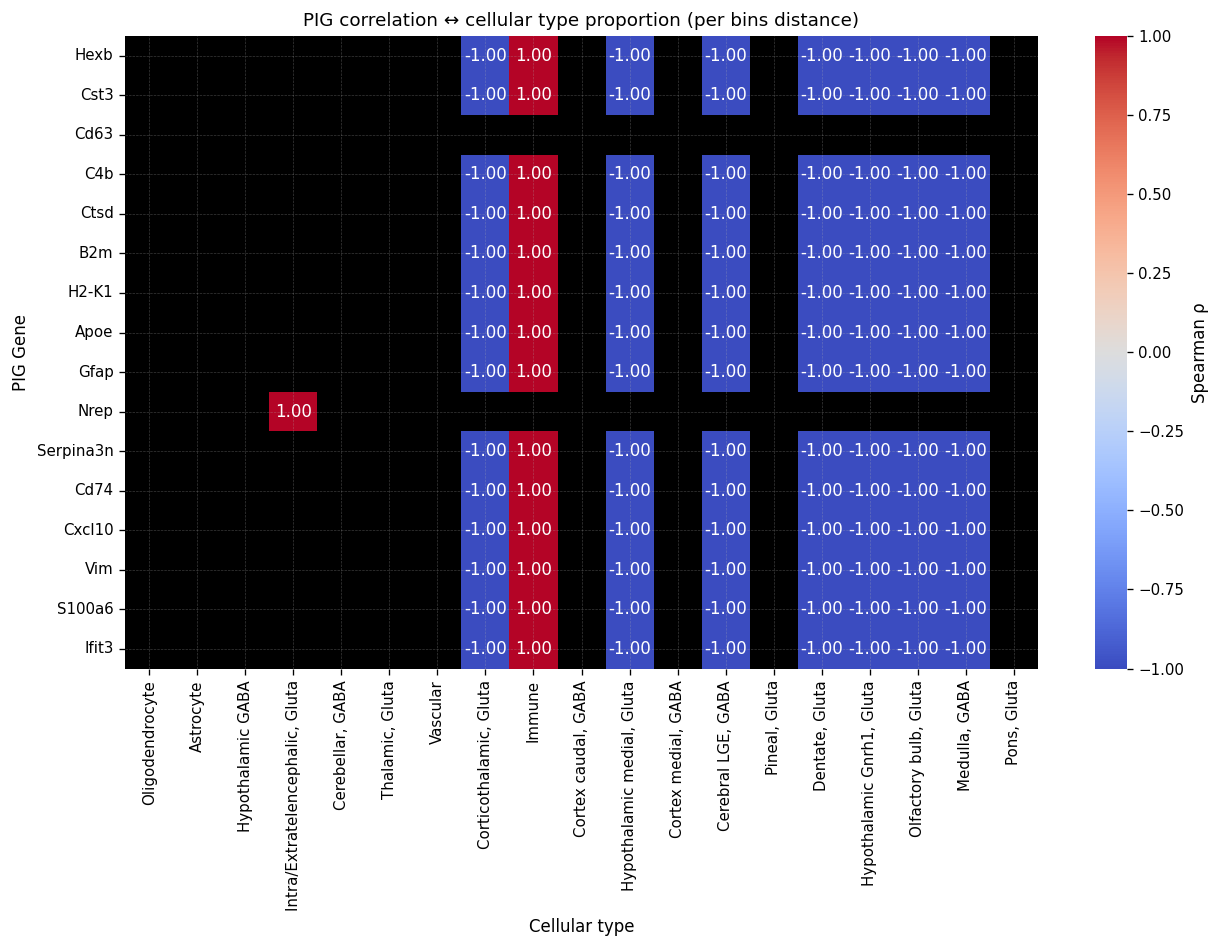

In [42]:
# Align matrices on same bins
cell_proportion_analytics = process_cell_annotations(
    combined_df_normalized_full, PATH_TO_ANNOTATIONS, logger=logger
)
props, cells = cell_proportion_analytics["props"], cell_proportion_analytics["cells"]
pivot_prop = props.pivot_table(
    index="distance_bin", columns="cell_type", values="proportion", aggfunc="mean"
).fillna(0)
props, cells = cell_proportion_analytics["props"], cell_proportion_analytics["cells"]
mean_by_bin = cells.groupby("distance_bin")[PIG_GENES].mean().reset_index()
pig_mat = mean_by_bin.set_index("distance_bin")[PIG_GENES]
prop_mat = pivot_prop.loc[pig_mat.index]  # align index
prop_mat = prop_mat.rename(columns=lambda c: expanded_types.get(c, c))
plot_pig_comp_heatmap(pig_mat, prop_mat, PIG_GENES)

<a id="rq3_reg"></a>
#### 5.c.ii. Regression of PIG expression on cell type composition and plaque distance

##### Mathematical formulation
- For each PIG gene $g$, we have:
    - $x_{ig}$ denoting the log normalized transcript count in cell $i$
    - $d_i$ denoting the distance (µm) to the nearest plaque
    - $t_i\in\mathcal{T}$ denoting the broad cell type, where
    $$
    \mathcal{T} =
    \{\text{Neuron\_Glutamatergic},\ \text{Neuron\_GABAergic},\ \text{Glia\_Oligodendrocyte\_Lineage},\ \text{Glia\_Astrocyte\_Ependymal},\ \text{Immune\_Microglia\_Macrophage},\ \text{Vascular\_Endothelial\_Pericyte}\}.
    $$
- We fit an ordinary least squares (OLS) model with treatment (dummy, i.e., $k-1$ indicators relative to a baseline $t_0$) coding for $\mathcal{T}$ and an intercept $\beta_{0g}$ :
  $$
  x_{ig} \,=\, \beta_{0g} \; + \; \beta_{dg}\, d_i \; + \; \sum_{t\in\mathcal{T}\setminus\{t_0\}} \gamma_{g,t}\, \mathbf{1}\{t_i=t\} \; + \; \varepsilon_{ig},
  \qquad \varepsilon_{ig} \stackrel{\mathrm{i.i.d.}}{\sim} \mathcal{N}(0,\sigma_g^2).
  $$
- We use the category $t_0=\text{Vascular\_Endothelial\_Pericyte}$ as a baseline. 
- Thus, each $\gamma_{g,t}$ is the offset for type $t$ relative to the $t_0=\text{Vascular\_Endothelial\_Pericyte}$ baseline.
- As part of the linear regression, we test the following null hypothesis:
  $$
  H_0:\ \beta_{dg}=0 \quad\text{(no distance effect)}
  $$
- As a result of running the linear regression, we will report the train $R^2$. 
- We compute it as follows.
- For predictions $\hat y_i$ and ground truth $y_i$ with mean $\bar y$, we compute
  $$
  R^2 \,=\, 1\; -\; \frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2},
  $$

##### Results and discussion
- For brevity, we only present the results for the Apoe gene.
- After simplifying `cell_type` into `broad_type` and fitting the linear model, we managed to explain 20.3% of the variance of the normalized transcript count ($R^2 = 0.203$).
- Using the F-test, we obtained an overall p-value below $2.13e-{174}$ (effectively equal to 0 and reported as `Prob (F-statistic): 0.00`).
- This means that we can confidently reject the joint null hypothesis $H_0$ of no significant effects.

| Term | Coef (log) | p-value | Natural-scale factor | Interpretation vs Vascular_Endothelial_Pericyte |
|---|---:|---:|---:|---|
| Intercept (at d=0, Vascular_Endothelial_Pericyte) | 1.8328 | < 1e-300 | exp(1.8328) − 1 ≈ 5.25 transcripts | Baseline expected expression at plaque surface |
| Glia_Astrocyte_Ependymal | +0.9494 | < 1e-300 | exp(0.9494) = 2.584× | 158% higher than baseline |
| Glia_Oligodendrocyte_Lineage | -0.0700 | 6.5e-06 | exp(-0.0700) = 0.932× | 6.8% lower than baseline |
| Immune_Microglia_Macrophage | +0.3562 | < 1e-300 | exp(0.3562) = 1.428× | 43% higher than baseline |
| Neuron_GABAergic | -0.0271 | 0.068 | exp(-0.0271) = 0.973× | 2.7% lower than baseline (not significant at 0.05) |
| Neuron_Glutamatergic | -0.1924 | < 1e-300 | exp(-0.1924) = 0.825× | 17.5% lower than baseline |
| distance_to_plaque (per µm) | -0.0012 | < 1e-300 | exp(-0.0012) = 0.9988× per µm | Each additional µm reduces expected expression by ~0.12% |

- From the table above, we can see a confirmation of our previous findings:
    - Neuronal populations, especially glutamatergic neurons, show reduced Apoe expression relative to the vascular reference.
    - Meanwhile, astrocyte and microglia populations are enriched in Apoe expression near plaques.
      - In other words, what little of Apoe remains around the plaques, is due to the astrocytes and microglia, not the depleted neuronal cells.
    - The GABAergic effect is small and not statistically significant at the 0.05 level in this specification, mirroring the previous findings on Cortex–medial ganglionic eminence GABAergic neurons.


In [43]:
# Fix: need to update "broad type"
cells["cell_type"] = cells["cell_type"].apply(lambda x: expanded_types.get(x))
apoe_summary_text, gene_coefs, binned_stats, cells, agg, bin_order = (
    analyze_plaque_distance_effects(
        cells,
        PIG_GENES,
        baseline_broad_type="Vascular_Endothelial_Pericyte",
        logger=logger,
    )
)

Creating 'broad_type' by simplifying 'cell_type'.

                            OLS Regression Results                            
Dep. Variable:              Q('Apoe')   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     2288.
Date:                Mon, 15 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:49:13   Log-Likelihood:                -59590.
No. Observations:               53895   AIC:                         1.192e+05
Df Residuals:                   53888   BIC:                         1.193e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                                                                          coef    std err          t      P>|t|      [0.025    

<a id="rq3_viz"></a>
#### 5.c.iii. Visualization of PIG expression by cell type and distance bin

##### Mathematical formulation
- For each gene g, broad type t, and distance bin b, let the set of cells be $I_{g,t,b}$ with size $n_{g,t,b}$ and log1p-normalized expression values $\{x_{ig}\}_{i\in I_{g,t,b}}$.
- The per-bin mean and standard error of the mean (SEM) are
  $$
  \bar x_{g,t,b} \,=\, \frac{1}{n_{g,t,b}}\sum_{i\in I_{g,t,b}} x_{ig},\qquad
  \mathrm{SEM}_{g,t,b} \,=\, \frac{s_{g,t,b}}{\sqrt{n_{g,t,b}}},\quad
  s_{g,t,b}^2 \,=\, \frac{1}{n_{g,t,b}-1}\sum_{i\in I_{g,t,b}} (x_{ig}-\bar x_{g,t,b})^2.
  $$
- The plotted confidence band uses a normal approximation (large n) to draw an approximate 95% CI as
  $$
  \bar x_{g,t,b} \,\pm\, 1.96\,\mathrm{SEM}_{g,t,b}.
  $$

##### Results and discussion
- Looking at the interactive plot in the following cell, we can confirm that Glia and Astrocyte Ependymal cells exhibit a higher transcript count of Apoe compared to Vascular Endothelial Pericyte cells.
- Further, Glutamatergic neurons show a much lower expression of Apoe in comparison.
- Further, the difference in expression (relative to the vascular cells) remains significant even after accounting for the 95% confidence interval.

In [65]:
interactive_comp_pig_regression_grid(agg, PIG_GENES, bin_order)

Saved to ./pig_by_distance_grid.html


<a id="rq4"></a>
### 5.d. Inferring plaque distance from gene expression

<a id="rq4_pred"></a>
#### 5.d.i. Predictive model benchmarking, explainability, and diagnostics

- In this section, we benchmark a number of predictive models to estimate the distance to plaque from a 347-gene expression vector. 
- We evaluate:
    - LASSO
    - ElasticNet
    - Random Forest
    - XGBoost
- In our analysis, we use a random 80/20 train/test split in terms of cells.
- For LASSO and ElasticNet, we standardize the log1p-transformed transcript counts.
- Meanwhile, we use unstandardized log1p-transformed transcript counts for tree models.
- As a result of the analysis, we report train and test $R^2$, feature importances, and the learned coefficients where appropriate.

##### Mathematical formulation

- We will now discuss the mathematical formulation of the models we used.
- LASSO linear regression model:
  $$
  \min_{\beta_0,\,\beta}\; \frac{1}{2n}\,\lVert y-\beta_0\mathbf{1}-X\beta\rVert_2^2\; +\; \lambda\,\lVert\beta\rVert_1,
  $$
    - The sparsity coefficient $\lambda>0$ encourages sparse $\beta$. 
    - Features in the design matrix $X$ are standardized.

- ElasticNet linear regression model:
  $$
  \min_{\beta_0,\,\beta}\; \frac{1}{2n}\,\lVert y-\beta_0\mathbf{1}-X\beta\rVert_2^2\; +\; \lambda\,\Big(\alpha\,\lVert\beta\rVert_1 + \tfrac{1-\alpha}{2}\,\lVert\beta\rVert_2^2\Big),\quad \alpha\in[0,1].
  $$
    - ElasticNet includes a mix of sparse and ridge regularization.
    - The parameter $\alpha\in[0,1]$ controls the mix.
    - With $\alpha=1$, ElasticNet reduces to LASSO; with $\alpha=0$ the model collapses to a ridge regression. 
    - Features in the design matrix $X$ are standardized.

- Random Forest:
  - Our implementation builds a tree ensemble and uses bagging.
  - Random forest trains $300$ regression trees on bootstrap samples.
  - Each tree has a maximum depth of 15 and at least 100 samples in leaf nodes.
  - At each decision split, the algorithm considers a random subset of features, which helps with importance discovery.
  - The final prediction is the average of tree outputs.
  - The gene importances are then computed with information gained by using this gene for the split.

- XGBoost:
  - This approach uses gradient boosting trees with 500 estimators, each with a maximum depth of 6.
  - The algorithm constructs an additive model $\hat y=\sum_{m=1}^M f_m(x)$ where each $f_m$ is a shallow regression tree.
  - $f_m$ is learned to minimize the squared error, with a penalty on the tree’s complexity.
  - The feature importances are computed in a similar manner as in the random forest.


##### Results & Discussion

| Model | Train $R^2$ | Test $R^2$ | Key hyperparams |
|---|---:|---:|---|
| LASSO | 0.1969 | 0.1955 | $\alpha=0.0678$ |
| ElasticNet | 0.1969 | 0.1955 | $\alpha=0.0702$, $\text{l1\_ratio}=0.9$ |
| Random Forest | 0.2252 | 0.1874 | — |
| XGBoost | 0.4784 | 0.2577 | — |

- According to the test $R^2$, we can rank the models as follows: 
    - XGBoost (0.258) > LASSO $\approx$ ElasticNet (0.196) > Random Forest (0.187).
- XGBoost shows the largest train–test gap (train $R^2=0.478$, test $R^2=0.258$), a sign of overfitting.
- This is consistent with a higher modeling capacity of XGBoost.
- However, its test performance is still the best, possibly due to the benefit of overparameterization.
- The LASSO and ElasticNet linear models have nearly matching train and test $R^2$.
- We can explain this due to the lower modeling capacity of these simpler models.

##### Explainability

- The top genes for predicting plaque distance are fairly consistent across all four models.
- Gfap and Spag16 appear in the top 5 for all models.
- Three out of four models rank Gfap (an astrocyte-associated PIG) as the top predictor of proximity to amyloid beta plaque, reinforcing our earlier findings.
- Other highly ranked genes include Spag16 and Lyz2, which are associated with glial and immune cells. 
- Agreement across both the linear and the tree-based models suggests that the top genes have a robust relationship with plaque proximity.
- This agrees with our previous findings, which revealed that Gfap peaks within the first 10 µm and declines with distance. 
- Meanwhile, lgf2 has an opposite trend, peaking at around 270 µm and declining towards the plaque.

#### elasticnet
| Rank | Gene | Importance |
|---:|---|---:|
| 1 | Gfap | 7.738978 |
| 2 | Spag16 | 3.780172 |
| 3 | Slc17a6 | 3.025042 |
| 4 | Slc17a7 | 2.953878 |
| 5 | Igf2 | 2.907111 |

#### lasso
| Rank | Gene | Importance |
|---:|---|---:|
| 1 | Gfap | 7.864686 |
| 2 | Spag16 | 3.801531 |
| 3 | Slc17a6 | 3.073279 |
| 4 | Slc17a7 | 3.057380 |
| 5 | Igf2 | 2.949014 |

#### rf
| Rank | Gene | Importance |
|---:|---|---:|
| 1 | Gfap | 0.228450 |
| 2 | Spag16 | 0.084622 |
| 3 | Lyz2 | 0.066671 |
| 4 | Cabp7 | 0.063918 |
| 5 | B2m | 0.034584 |

#### xgb
| Rank | Gene | Importance |
|---:|---|---:|
| 1 | Spag16 | 0.033058 |
| 2 | Lyz2 | 0.023342 |
| 3 | Gfap | 0.016999 |
| 4 | Igf2 | 0.015752 |
| 5 | Strip2 | 0.013022 |

##### XGBoost diagnostics

- The distribution of residuals of the XGBoost model reveals clear heteroscedasticity.
  - Instead of being uniformly dotted around the horizontal zero line, the residuals show a linear trend: most near to the plaque, the model tends to over-predict, and the further away, the more it under-predicts.
- We can see that most of the distribution's mass is concentrated the [0, 100] µm range.
- In other words, the model doesn't utilize the full target range.
- Plotting the residuals against the brain tissue reveals non-uniform distribution that is clearly aligned with the plaque centroids shown as red stars.
- The residuals tend to fall into 3 broad categories:
  - 25.51% are highly negative (under -17.2 µm) and appear close to the plaque (within 49 µm)
  - 28.15% are highly positive (over 10.6 µm) and appear further away (beyond 87 µm)
  - 20.94% are moderate residuals (between -17.2 and 10.6 µm) and appear between 49 and 87 µm
- This heteroscedasticity implies that the model is missing important covariates.
- Looking at the per-cell residuals, we can see that the average error is largest in Hypothalamic GnRH1-expressing glutamatergic neurons. 
- This is likely due to the fact that, as discussed before, these cells are located in the third ventricle, which is the furthest away from plaques than any other brain region. As a result, most residuals in this cluster are in the highly positive (over 10.6 µm) bracket.
- Meanwhile, Pons glutamatergic neurons exhibit the lowest mean absolute residuals, indicating that the model performs best in this region.


X shape: (53895, 347)
y shape: (53895,)
Target NaN count: 0
Train shape: (43116, 347), Test shape: (10779, 347)
Mean of first 5 genes (train, after scaling): [ 1.14430710e-13 -3.42399272e-14 -7.94046875e-15 -5.57890675e-15
 -5.43266661e-17]
Std  of first 5 genes (train, after scaling): [1. 1. 1. 1. 1.]
Running LASSO
Running ELASTICNET
Running RF
Running XGB
Model performance summary created.
        model  train_r2   test_r2     alpha  l1_ratio
0       lasso  0.196916  0.195518  0.067777       NaN
1  elasticnet  0.196918  0.195452  0.070232       0.9
2          rf  0.225236  0.187433       NaN       NaN
3         xgb  0.478434  0.257721       NaN       NaN


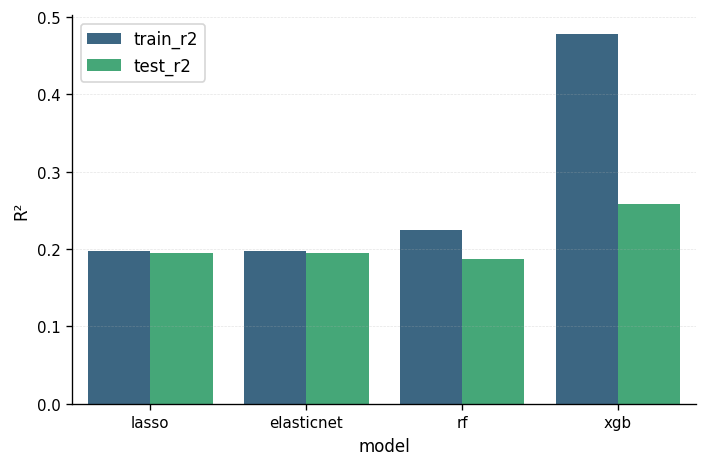

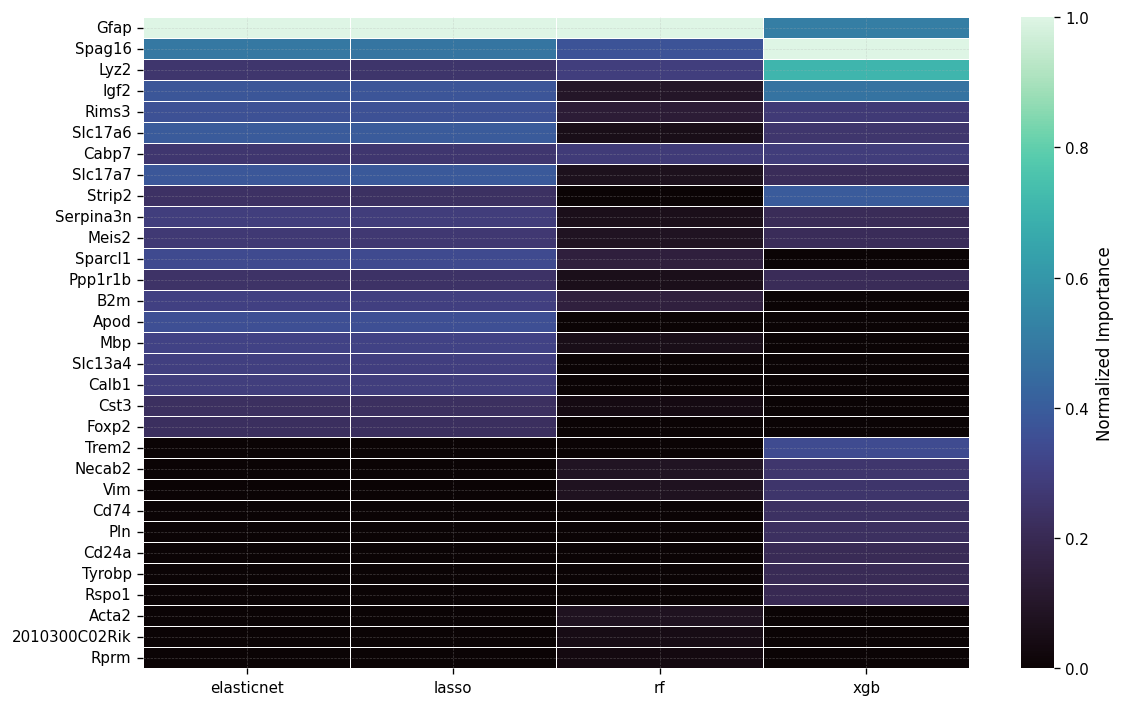

Top genes for XGB: ['Spag16', 'Lyz2', 'Gfap', 'Igf2', 'Strip2']


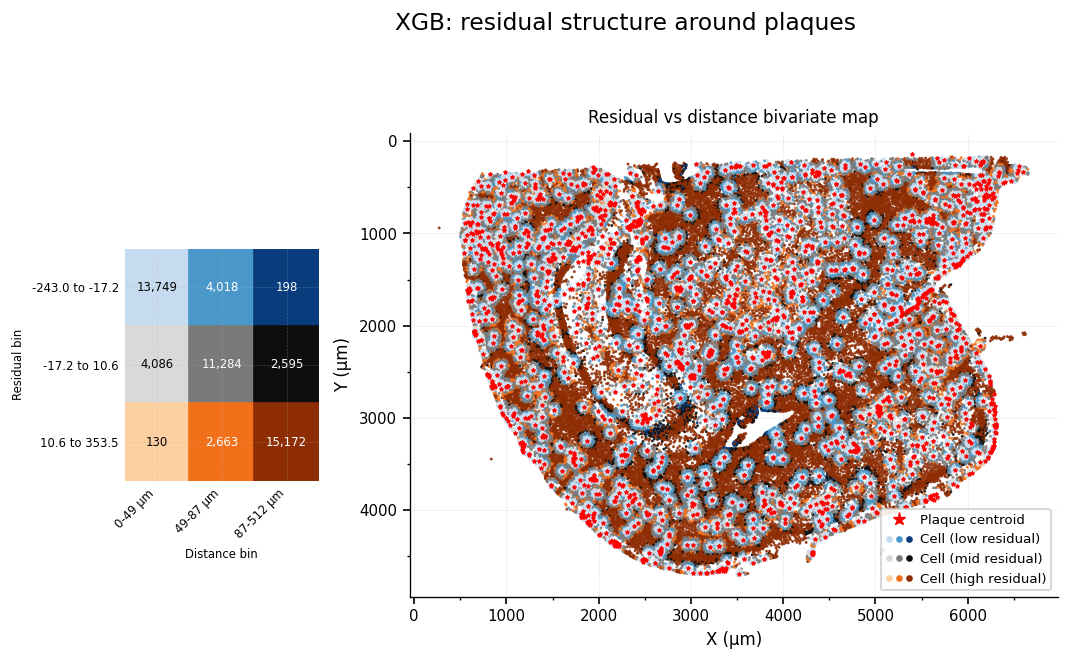

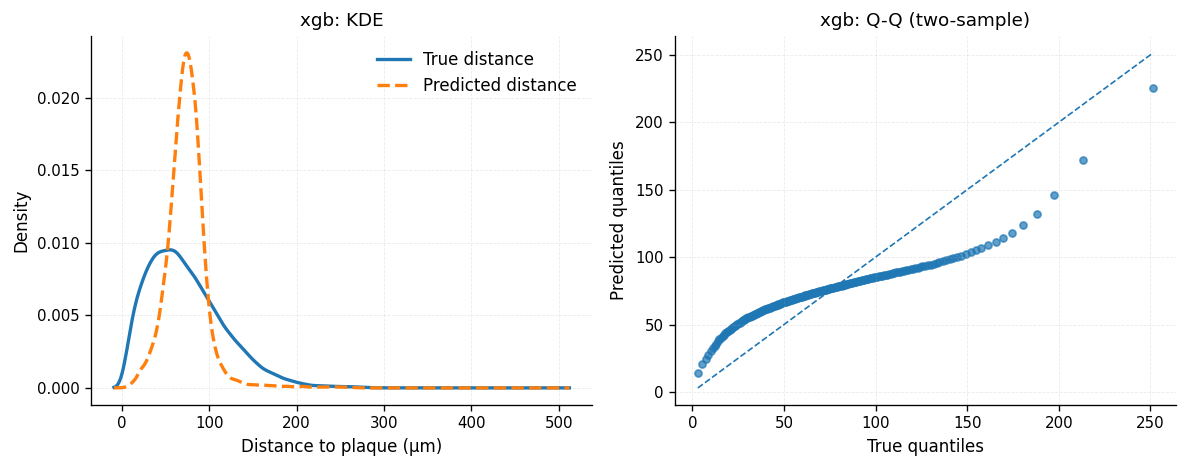

Pearson r = 0.86


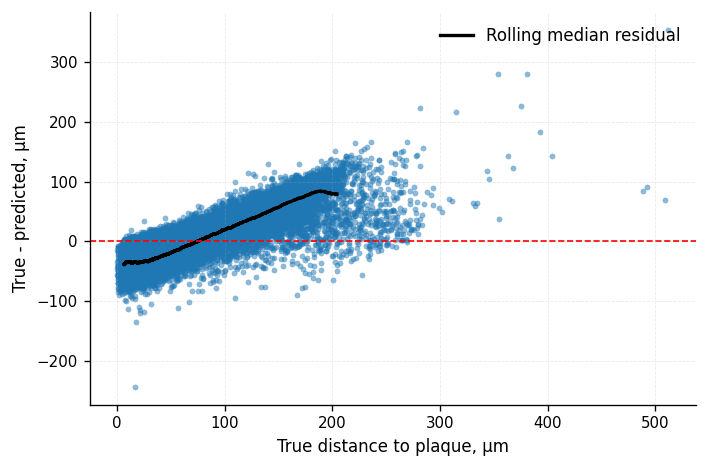

Plp1       0.114298
Apod       0.112920
Cnp        0.087968
Mobp       0.081186
Gjc3       0.059350
Opalin     0.043888
Gatm       0.042735
Sox10      0.025557
Mbp        0.021959
Zfp536     0.019419
Itgb4      0.017036
Olig2      0.013634
Igf2       0.012522
Plekhb1    0.010685
Gsn        0.010632
dtype: float64
Gene modeling pipeline completed.


In [45]:
# ToDo: do a "confusion matrix" style plot
if not "plaque_x" in combined_df_normalized_full.columns: # make this idempotent
    plaques_poly.rename(columns={"centroid_x": "plaque_x", "centroid_y": "plaque_y"}, inplace=True)
    combined_df_normalized_full = combined_df_normalized_full.join(
        plaques_poly.set_index("plaque_id")[["plaque_x", "plaque_y"]],
        how="left",
        on="nearest_plaque_id",
    )
model_runners = {
    "lasso": pm.run_lasso,
    "elasticnet": pm.run_elasticnet,
    "rf": pm.run_rf,
    "xgb": pm.run_xgb,
}
out = run_gene_distance_modeling(
    cells_with_distances=combined_df_normalized_full,
    gene_cols=gene_cols,
    model_runners=model_runners,
    best_model_name="xgb",
    plot_model_performance=plot_model_performance,
    plot_top_gene_importances=plot_top_gene_importances,
    plaques_poly=plaques_poly,
    logger=logger,
    plot_bivariate_resid_dist_spatial=plot_bivariate_resid_distance_spatial,
    plot_radius_color_spatial=None,
    plot_true_pred_kde=plot_true_pred_kde,
    plot_residual_vs_distance=plot_residual_vs_distance,
)

In [68]:
df = out.importance_df.copy()

top5 = (
    df.sort_values(["model", "importance"], ascending=[True, False])
      .groupby("model", as_index=False)
      .head(5)
)

for model, sub in top5.groupby("model"):
    print(f"\n=== {model} (top 5) ===")
    print(sub[["gene", "importance"]].to_string(index=False))


=== elasticnet (top 5) ===
   gene  importance
   Gfap    7.738978
 Spag16    3.780172
Slc17a6    3.025042
Slc17a7    2.953878
   Igf2    2.907111

=== lasso (top 5) ===
   gene  importance
   Gfap    7.864686
 Spag16    3.801531
Slc17a6    3.073279
Slc17a7    3.057380
   Igf2    2.949014

=== rf (top 5) ===
  gene  importance
  Gfap    0.228450
Spag16    0.084622
  Lyz2    0.066671
 Cabp7    0.063918
   B2m    0.034584

=== xgb (top 5) ===
  gene  importance
Spag16    0.033058
  Lyz2    0.023342
  Gfap    0.016999
  Igf2    0.015752
Strip2    0.013022


In [86]:
# Residuals
combined_df_normalized_full["residual"] = (
    combined_df_normalized_full["nearest_plaque_center_dist"] - out.y_pred
)

# Merge clusters
combined_df_normalized_full_with_clusters = combined_df_normalized_full.merge(
    clustered_df_by_mouse_joint["tg-17"][["cell_id", "cluster_leiden"]],
    on="cell_id",
    how="inner",
)

# Aggregate residuals by cluster (use mean; also show counts)
cluster_stats = (
    combined_df_normalized_full_with_clusters
    .groupby("cluster_leiden")["residual"]
    .agg(n="size", mean_residual="mean", mean_abs_residual=lambda s: np.mean(np.abs(s)))
)

# Cluster with largest and smallest mean absolute residual
largest_abs = cluster_stats["mean_abs_residual"].idxmax()
smallest_abs = cluster_stats["mean_abs_residual"].idxmin()

print("Cluster with LARGEST mean(|residual|):")
print(cluster_stats.loc[[largest_abs]].to_string())

print("\nCluster with SMALLEST mean(|residual|):")
print(cluster_stats.loc[[smallest_abs]].to_string())


Cluster with LARGEST mean(|residual|):
                  n  mean_residual  mean_abs_residual
cluster_leiden                                       
15              917        2.80705          32.229535

Cluster with SMALLEST mean(|residual|):
                  n  mean_residual  mean_abs_residual
cluster_leiden                                       
18              499       1.713778          17.874581


In [87]:
results['my_label_to_type']

{0: 'Oligodendrocyte',
 1: 'Astrocyte',
 2: 'Hypothalamic GABA',
 3: 'Intra/Extratelencephalic, Gluta',
 4: 'Cerebellar, GABA',
 5: 'Thalamic, Gluta',
 6: 'Vascular',
 7: 'Corticothalamic, Gluta',
 8: 'Immune',
 9: 'Cortex caudal, GABA',
 10: 'Hypothalamic medial, Gluta',
 11: 'Cortex medial, GABA',
 12: 'Cerebral LGE, GABA',
 13: 'Pineal, Gluta',
 14: 'Dentate, Gluta',
 15: 'Hypothalamic Gnrh1, Gluta',
 16: 'Olfactory bulb, Gluta',
 17: 'Medulla, GABA',
 18: 'Pons, Gluta'}

In [46]:
log_runtime(_nb_start_time, time.time())

Total runtime: 350.5 seconds
